# Code example: Benchmarking Translation Fidelity Between Legacy RTMs and TorchRTM

### **TorchRTM: A high-performance Vegetation RTM package for deep learning integration**
**Authors:**  
Peng Sun, Peter van Bodegom, Marco D. Visser

## Introduction

A critical step in validating TorchRTM is demonstrating that its GPU-accelerated (fully differentiable) implementation faithfully reproduces the behaviour of established legacy radiative transfer models. This “translation fidelity” assessment is a check to ensure that improvements in speed, scalability, and deep-learning integration do not come at the cost of physical correctness or numerical reliability.

The code below provides a concise benchmarking workflow. It runs identical input configurations through both the legacy RTM implementation and TorchRTM, compares their spectral outputs, and quantifies agreement using standard metrics (e.g. RMSE, relative error, correlation).

### Background for beginners: why is this needed?
This section shows that the “modernized” deep-learning-ready implementation still matches trusted reference models. We include it to offer a reproducible, parameter-controlled framework for quantifying agreement across spectral variables (e.g. reflectance, transmittance, canopy terms).Agreement is an _ABOSULUTE_ prerequisite before the computational and architectural benefits of torchRTM can be used for modern hybrid physics-AI workflows.


### Goal
The goal is to offer a reproducible test of numerical equivalence, or  highlights any implementation-level divergences.  

### Result
The code and graphs generated below offer a practical demonstration that TorchRTM maintains the scientific validity of the original models while enabling modern GPU-accelerated computation.

## Conclusion
The below benchmarks provide a basic foundation for confidence in subsequent forward simulations, inversion tasks, and physics-informed learning applications or integration into other hybrid machine-learning frameworks


 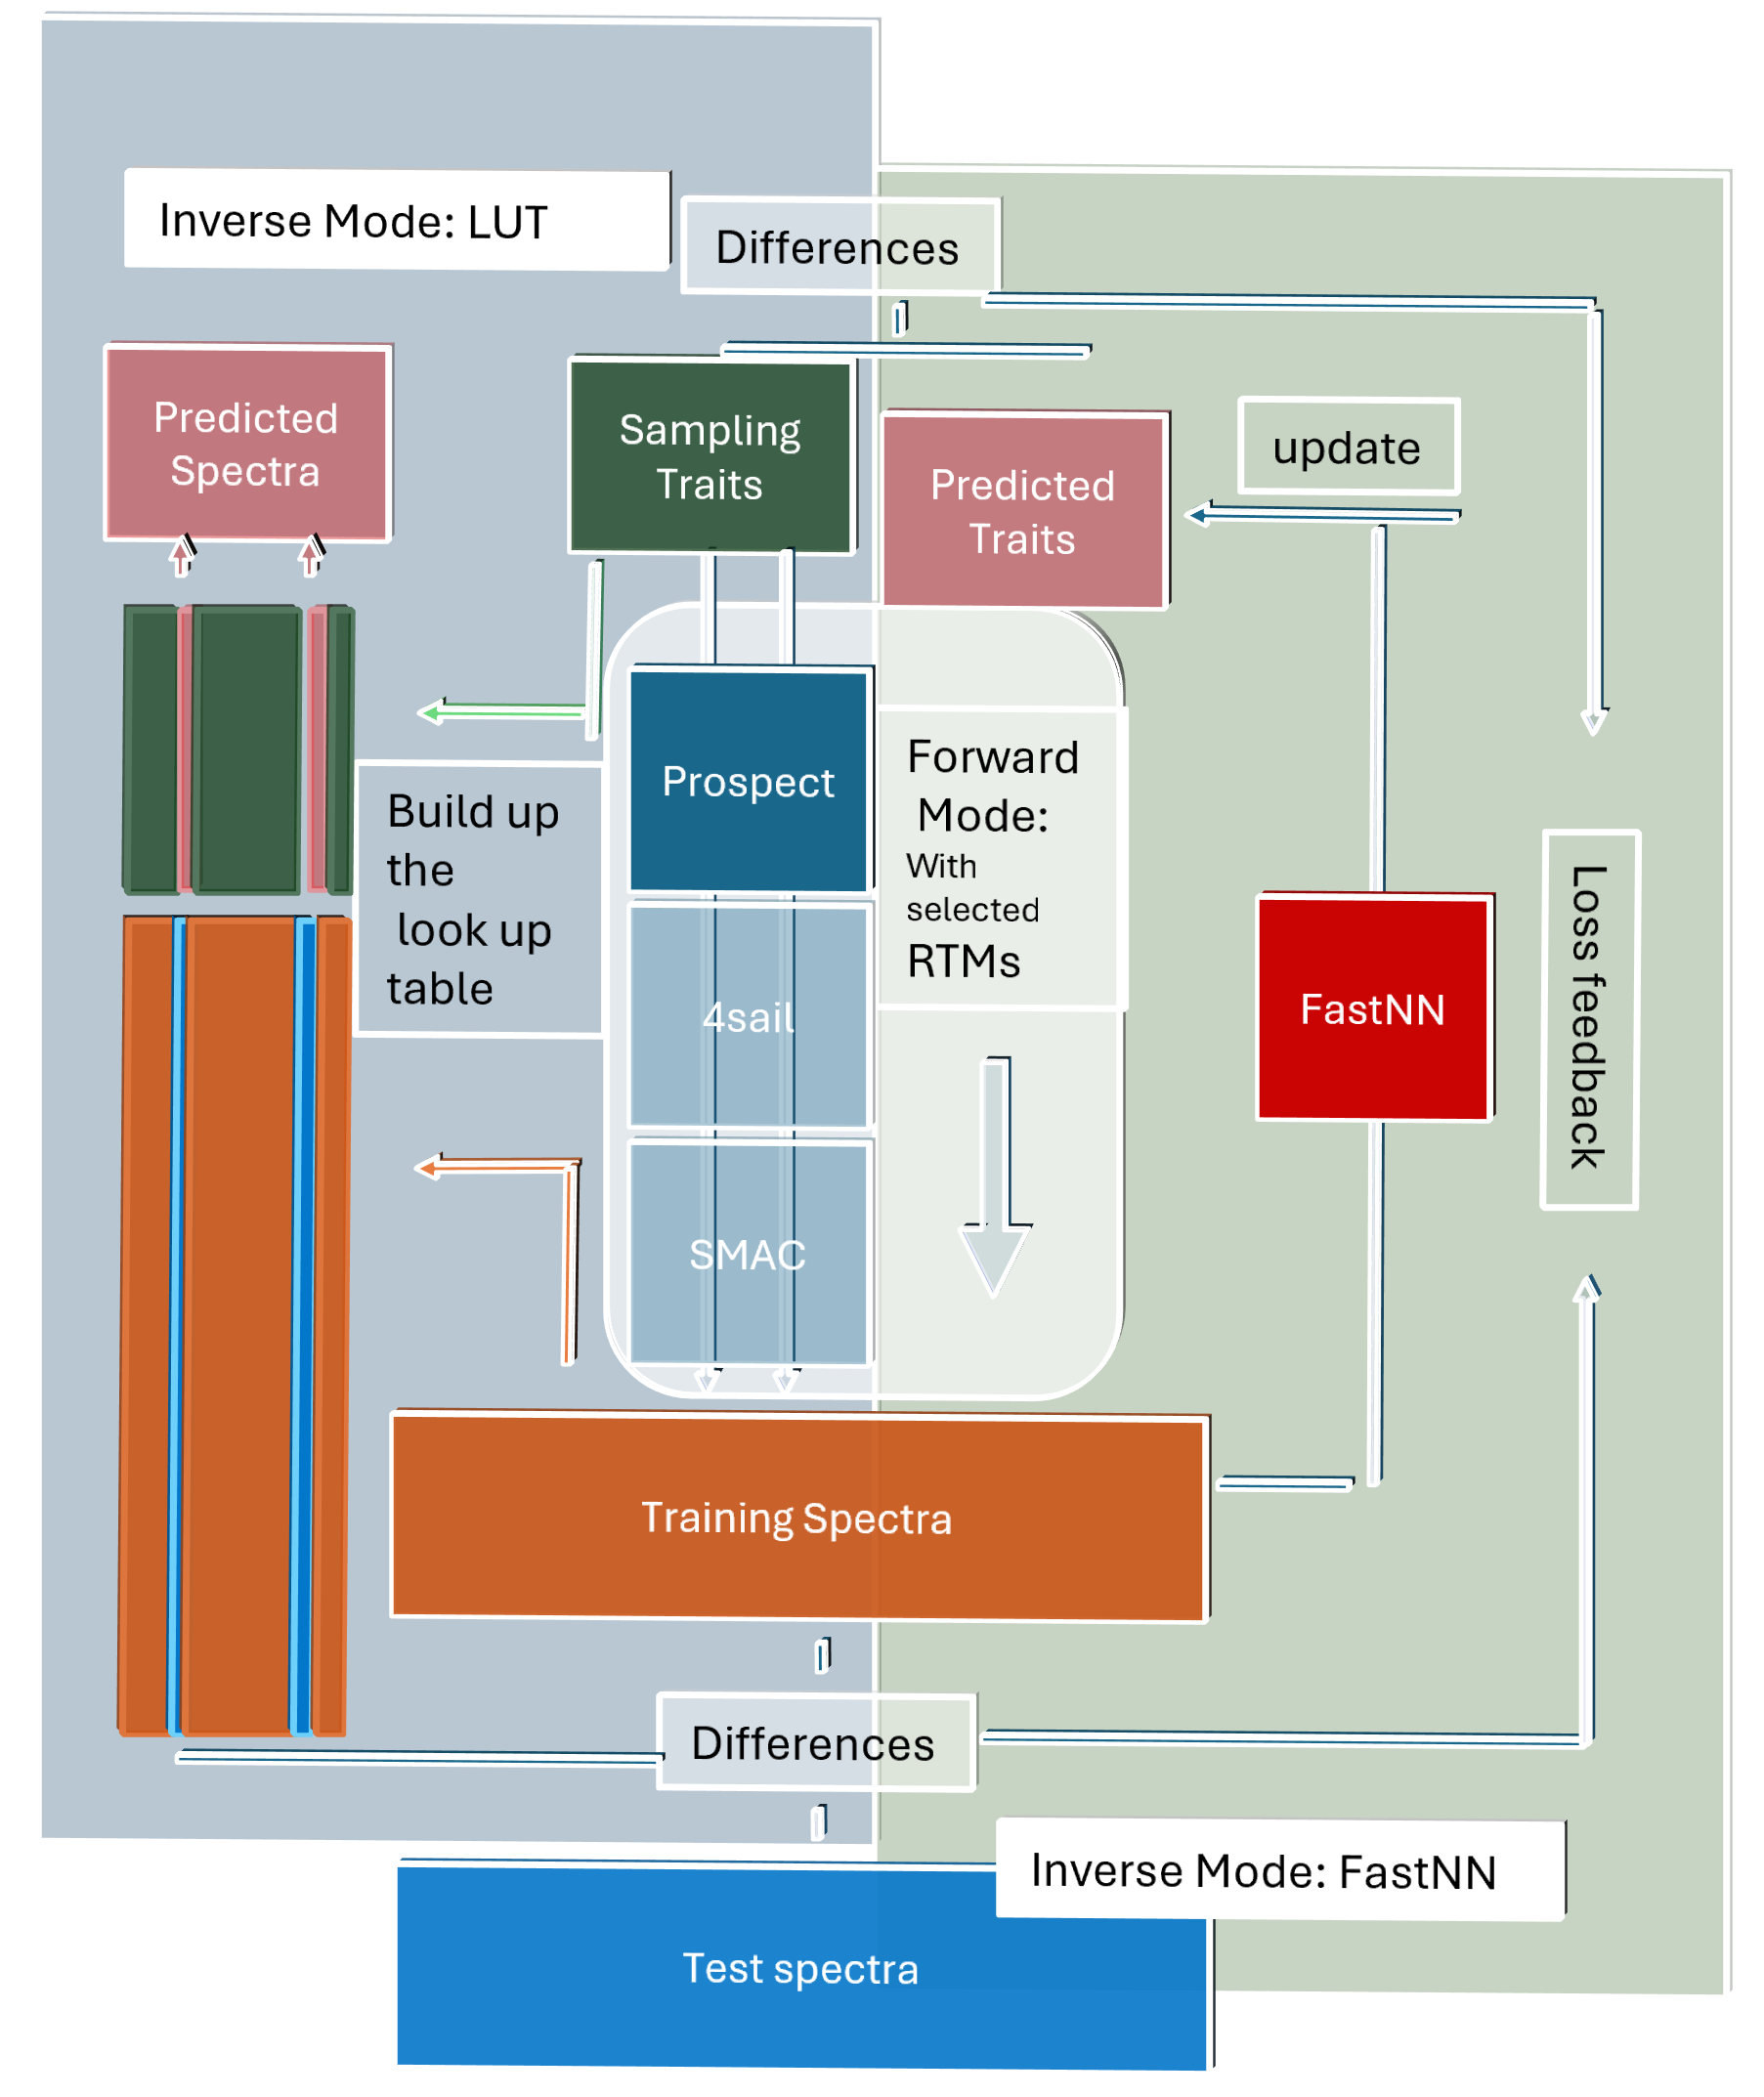

At the time of code testing the system information was:



In [1]:
# @title Extract GPU information
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Jan  5 11:27:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0  On |                  N/A |
|  0%   30C    P8             23W /  350W |    6708MiB /  24576MiB |     39%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Setup dependancies

We start by loading the libraries required. Configuring the runtime environment, and setting the parameters required for Prospect+4sail+Smac, and by defining any helper functions.

Install torchrtm package

In [ ]:
!pip install torchrtm

Load all required packages, set the working directory, and configure the computing device.  


In [3]:
# Standard Libraries
import datetime
import os
import time
import warnings
import random
from math import pi

# Third-Party Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, recall_score
)
from scipy.special import exp1, betainc
from scipy.stats import qmc
import torch
from torch import sin, cos, tan, acos, asin, log, pow, sqrt, square, exp
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.autograd import Variable
import torch.nn.functional as F
import torch.utils.benchmark as benchmark
from tqdm import tqdm
#from google.colab import drive  ## colab nolonger support the Fortran and matlab program now. Plz run this test demonstration by the PC with linux system

# Custom Modules from torchrtm package
from torchrtm.leaf.prospect import prospect5b, prospectd
from torchrtm.utils.torchlut import Torchlut
from torchrtm.models import prosail
from torchrtm.retrival.fastLUT import Torchlut_pred
from torchrtm.retrival.fastNN import Inverse_Net
from torchrtm.utils.spectradataset import SpectraDataset
from torchrtm.data_loader import load_soil_spectra
from torchrtm.utils.torch_utils import normalize_parameters


#drive.mount('/content/drive')
# Suppress warnings
warnings.filterwarnings("ignore")
# Configure device for computation
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

dry_soil, wet_soil = load_soil_spectra(device=device)


### Helper functions

Define functions for converting between torch tensors and numpy arrays.  


In [6]:
def to_cuda(x):
    """Converts data to a CUDA tensor."""
    return torch.tensor(x, dtype=torch.float32).to(device)
def to_np(x):
    """Converts a tensor to a NumPy array."""
    return x.detach().cpu().numpy()
import numpy as np
import random
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  #
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)


Load the required parameters for the PROSPECT-5, 4SAIL, and SMAC models.  


Set up the random seed

In [7]:
import numpy as np
import random
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  #
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

Visulisation function for the test of backward mode

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

def plot_regressions(y_true, y_pred, feature_names=None, xy_same=True):
    """
    Plot regression scatter plots for each feature and output a performance table (r², RMSE, Slope).

    Parameters
    ----------
    y_true, y_pred : array-like or DataFrame
        True and predicted values with the same shape. Each column represents one feature.
    feature_names : list of str, optional
        Custom feature names. If None, use the column names of y_true.
    xy_same : bool, default=True
        If True, force the same x/y limits and draw 1:1 line.
    """
    assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape" #, sharex=True, sharey=True

    n_features = y_true.shape[1]
    if feature_names is None:
        feature_names = y_true.columns

    metrics = []

    fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5), dpi=300)
    if n_features == 1:
        axes = [axes]
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for i, name in enumerate(feature_names):
        # Remove missing values
        mask = ~(np.isnan(y_true[:, i]) | np.isnan(y_pred[:, i]))
        yt = y_true[:, i][mask]
        yp = y_pred[:, i][mask]

        # Compute r², RMSE, slope
        corr = np.corrcoef(yt, yp)[0, 1]
        r2 = corr ** 2
        rmse = np.sqrt(np.mean((yt - yp) ** 2))
        slope, intercept, _, _, _ = linregress(yt, yp)

        metrics.append({'Feature': name, 'r2': r2, 'RMSE': rmse, 'Slope': slope})

        # Plot scatter
        ax = axes[i]
        ax.scatter(yt, yp, alpha=0.6, edgecolor='k')

        # Regression line
        xline = np.linspace(min(yt.min(), yp.min()), max(yt.max(), yp.max()), 100)
        if xy_same:
            ax.plot(xline, slope * xline + intercept, 'r--', label='Fit')
            ax.plot(xline, xline, 'k-', label='1:1')

        ax.set_title(name, fontsize=20)

        # Remove inner labels
        if i > 0:
            ax.set_ylabel('')
        ax.set_xlabel('' if i < n_features - 1 else 'True')

        # Keep the same range for both axes (optional)
        if xy_same:
            minv = min(yt.min(), yp.min())
            maxv = max(yt.max(), yp.max())
            margin = 0.05 * (maxv - minv)
            minv -= margin
            maxv += margin
            ax.set_xlim(minv, maxv)
            ax.set_ylim(minv, maxv)
            ax.set_aspect('equal', adjustable='box')
            #print(maxv)
        # Text box with metrics
        txt = f"r²={r2:.2f}\nRMSE={rmse:.4f}\nSlope={slope:.2f}"
        ax.text(
            0.95, 0.05, txt,
            ha='right', va='bottom', transform=ax.transAxes,
            fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    # Set shared x and y labels only once
    fig.text(0.5, 0.003, 'Observed Values', ha='center', fontsize=24)
    fig.text(0.04, 0.5, 'Predicted Values', va='center', rotation='vertical', fontsize=24)

    plt.tight_layout(rect=[0.06, 0.06, 1, 1])
    plt.show()

    metrics_df = pd.DataFrame(metrics)
    return metrics_df


# Forward Mode: Demonstrating the Core RTM Workflow



Before evaluating "translation fidelity" between legacy RTMs and TorchRTM, we demonstrate how forward mode operates within the new torchRTM framework. As with previous models, forward mode represents the fundamental building block of any radiative transfer model study. So understanding this is teh first step to understanding translation fidelity.

Here we - given biophysical traits and viewing conditions - simulate leaf-level optical properties, then canopy reflectance, and then top-of-atmosphere (TOA) signals.

The examples below illustrate a typical workflow of this progression. We first generate random biophysical traits and use them to run the PROSPECT-5D leaf model, followed by the combined PROSAIL canopy model, and finally apply SMAC-based atmospheric correction to produce TOA reflectance for a range of supported satellite sensors. These steps show how TorchRTM handles the standard multi-level (leaf to canopy to atmosphere) simulation but now ofcourse in a fully differentiable, GPU-accelerated environment.

For beginners: this forward-simulation workflow provides the foundation upon which all subsequent analyses—such as inversion, PINN integration, and the translation-fidelity benchmark—are built. However, it may be better to start with our tutorial.

The code below does assume some familiarity with RTMs, python, pyTorch and the legacy code.

## Generate the random traits and parameters as the input

In this section, we set the batch size to 5 and generate a random matrix to serve as the input for all forward-based simulations.

In [9]:

test_num = 5

# Set up the scale for each parameters
many_paras = torch.rand(test_num,18,dtype = torch.float32).to(device)
real_paras = normalize_parameters(many_paras[:,:15],fitting = False)
atom_papra = normalize_parameters(many_paras[:,15:],fitting = False,param_type='atom')


lai = real_paras[:,0]
LIDFa = real_paras[:,1]
LIDFb = real_paras[:,2]
q = real_paras[:,3]
tts = real_paras[:,4]
tto = real_paras[:,5]
psi = real_paras[:,6]
psoil = real_paras[:,7]
N = real_paras[:,8]
Cab = real_paras[:,9]
Car = real_paras[:,10]
Cbrown = real_paras[:,11]
Cw = real_paras[:,12]
Cm = real_paras[:,13]
Canth = real_paras[:,14]
alpha = torch.tensor(40).to(device).expand([test_num])
tran_alpha = alpha.clone()
aot550 = atom_papra[:,0]
uo3 = atom_papra[:,1]
uh2o = atom_papra[:,2]
traits = torch.stack([Cab,Car,Canth,Cbrown,Cw,Cm],axis = 1)



In this section, we demonstrate the use of forward mode to generate simulated spectra in parallel. We will execute the entire **PROSPECT-4SAIL-SMAC** process and visualize the results of each step.

## Run on forward mode

### Prospect5d

Simulate the processing of the prospect model

In [10]:
rho,tau = prospectd(traits,N, alpha = alpha,print_both = True)


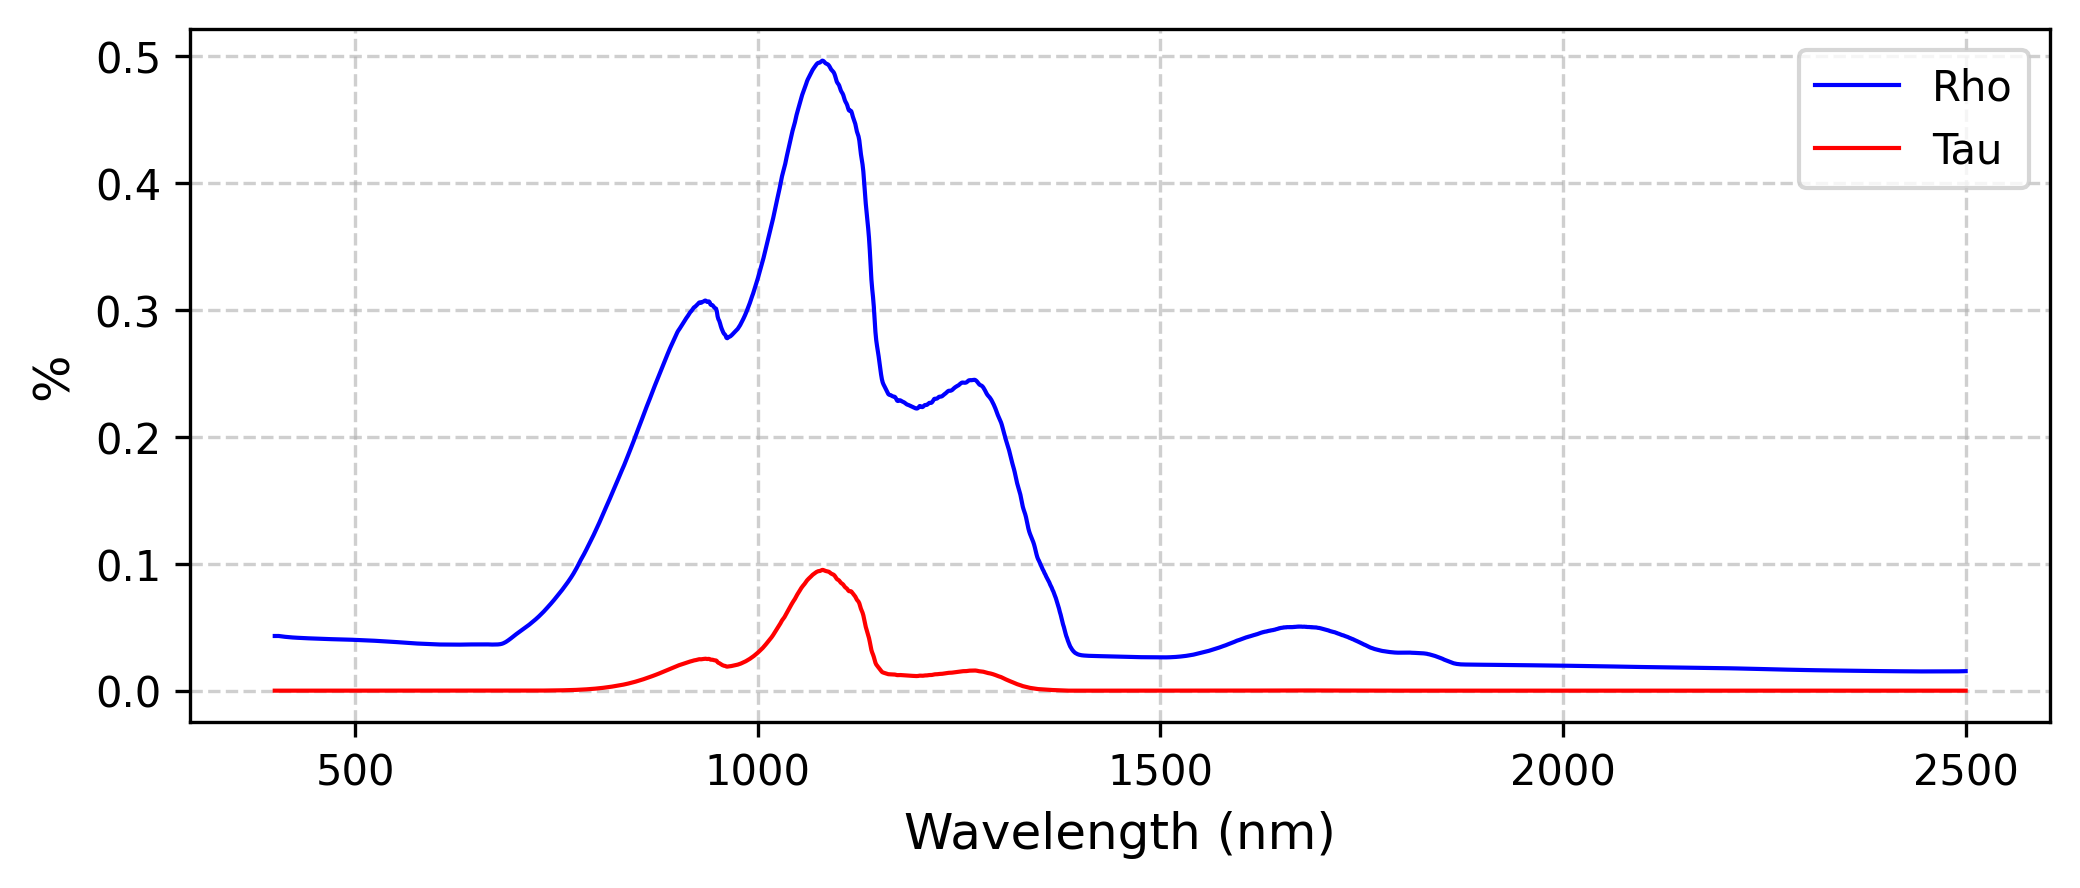

In [11]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
# define the wavelength
wavelengths = np.arange(400, 2501)
# create the figure
plt.figure(figsize=(8, 3), dpi=300)
plt.plot(wavelengths, to_np(rho[0]), label='Rho', color='b', linewidth=1)
plt.plot(wavelengths, to_np(tau[0]), label='Tau', color='r', linewidth=1)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('%', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Prospect5d + 4sail

Simulate the prosail processing

In [17]:
from torchrtm.leaf.prospect import prospect5b, prospectd


In [21]:
toc = prosail(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,alpha,psoil,batch_size=5000,prospect_type='prospect5d',lidtype=2)

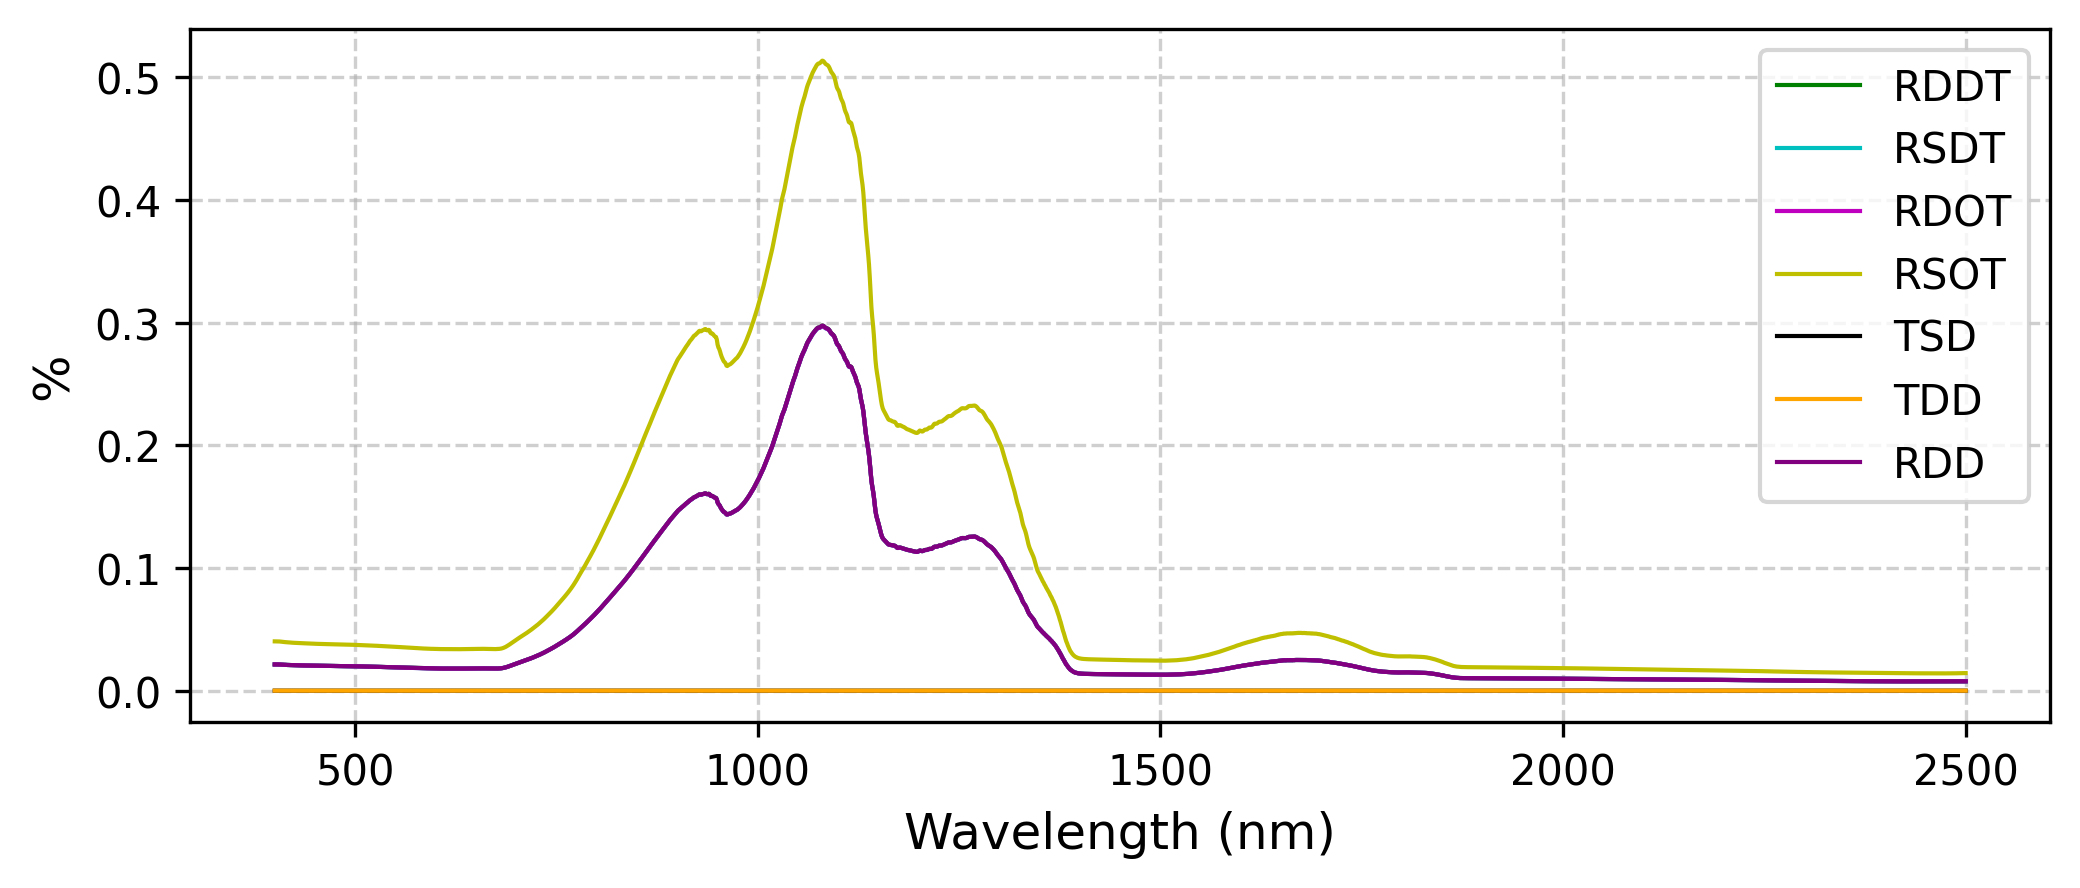

In [22]:
# @title
rddt, rsdt, rdot, rsot, tsd, tdd, rdd = toc
rddt, rsdt, rdot, rsot, tsd, tdd, rdd = rddt.t(), rsdt.t(), rdot.t(), rsot.t(), tsd.t(), tdd.t(), rdd.t()
# define the wavelength
wavelengths = np.arange(400, 2501)

# create the figure
plt.figure(figsize=(8, 3), dpi=300)
plt.plot(wavelengths, to_np(rddt[0]), label='RDDT', color='g', linewidth=1)
plt.plot(wavelengths, to_np(rsdt[0]), label='RSDT', color='c', linewidth=1)
plt.plot(wavelengths, to_np(rdot[0]), label='RDOT', color='m', linewidth=1)
plt.plot(wavelengths, to_np(rsot[0]), label='RSOT', color='y', linewidth=1)
plt.plot(wavelengths, to_np(tsd[0]), label='TSD', color='k', linewidth=1)
plt.plot(wavelengths, to_np(tdd[0]), label='TDD', color='orange', linewidth=1)
plt.plot(wavelengths, to_np(rdd[0]), label='RDD', color='purple', linewidth=1)

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('%', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### SMAC

Load the remote sensing parameters for bands

Show the list of supported satellites.

In [23]:
from torchrtm.data.check_info_scrap import get_rs_info
names = get_rs_info()


LANDSAT4-TM.pkl
Sentinel3A-OLCI.pkl
TerraAqua-MODIS.pkl
Sentinel3B-OLCI.pkl
Sentinel2B-MSI.pkl
Sentinel2A-MSI.pkl
LANDSAT7-ETM.pkl
LANDSAT5-TM.pkl
LANDSAT8-OLI.pkl


Generate TOA (Top of Atmosphere) values based on the parameters of each satellite



In [24]:
from torchrtm.atmosphere.smac import smac
from torchrtm.data_loader import load_smac_sensor
toa_results = []

from torchrtm.atmosphere.smac import toc_to_toa


#for _ in [(names[0])]:
for _ in (names):

  coefs,sm_wl = load_smac_sensor(_.split('.')[0])
  Ta_s, Ta_o, T_g, ra_dd, ra_so, ta_ss, ta_sd, ta_oo, ta_do = smac(tts,tto,psi,coefs)
  # return to the R_TOA
  R_TOC, R_TOA = toc_to_toa(toc.permute(0, 2, 1).to(device), sm_wl-400, ta_ss, ta_sd, ta_oo, ta_do, ra_so, ra_dd, T_g, return_toc=True)
  toa_results.append([sm_wl,R_TOA])

Attempting to load sensor: LANDSAT4-TM
Attempting to load sensor: Sentinel3A-OLCI
Attempting to load sensor: TerraAqua-MODIS
Attempting to load sensor: Sentinel3B-OLCI
Attempting to load sensor: Sentinel2B-MSI
Attempting to load sensor: Sentinel2A-MSI
Attempting to load sensor: LANDSAT7-ETM
Attempting to load sensor: LANDSAT5-TM
Attempting to load sensor: LANDSAT8-OLI


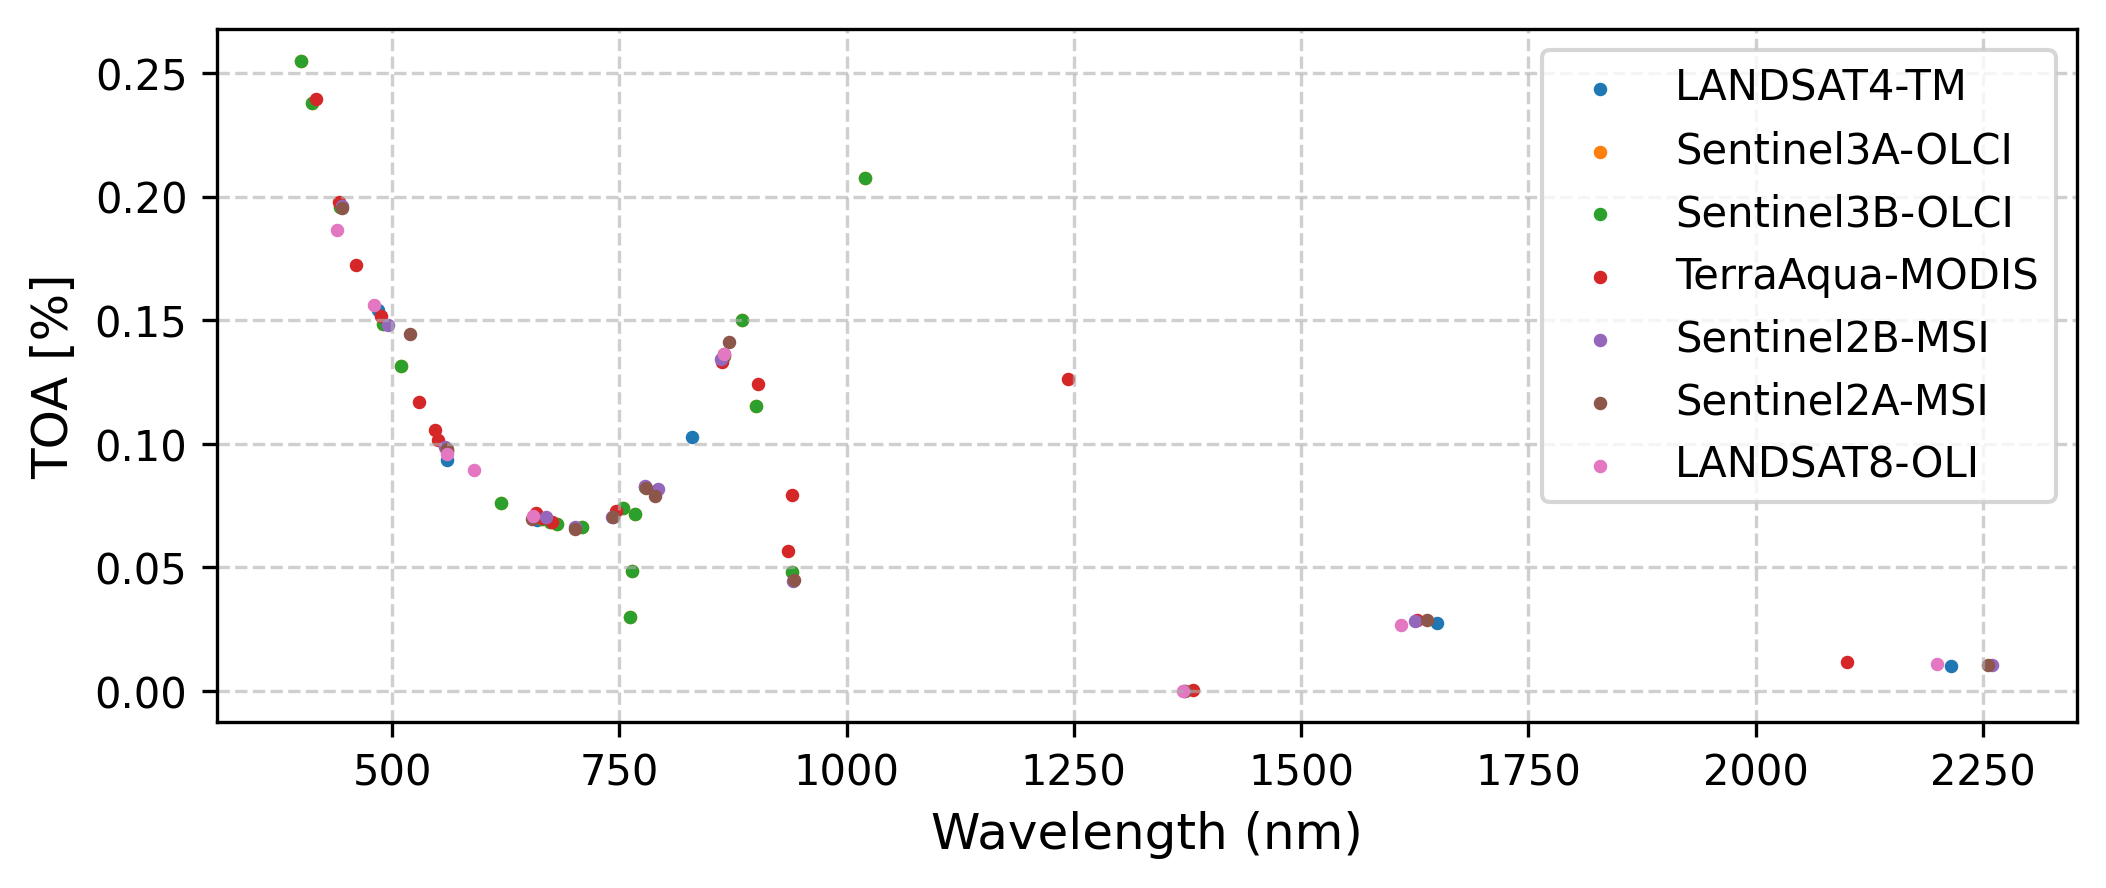

In [25]:
# @title
# Generate
sensor_list = names

plt.figure(figsize=(8, 3), dpi=300)
for _ in [0,1,3,2,4,5,8]:
  plt.scatter(toa_results[_][0], (toa_results[_][1][0].detach().cpu().numpy()), label=sensor_list[_].split('.')[0],s = 5)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('TOA [%]', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

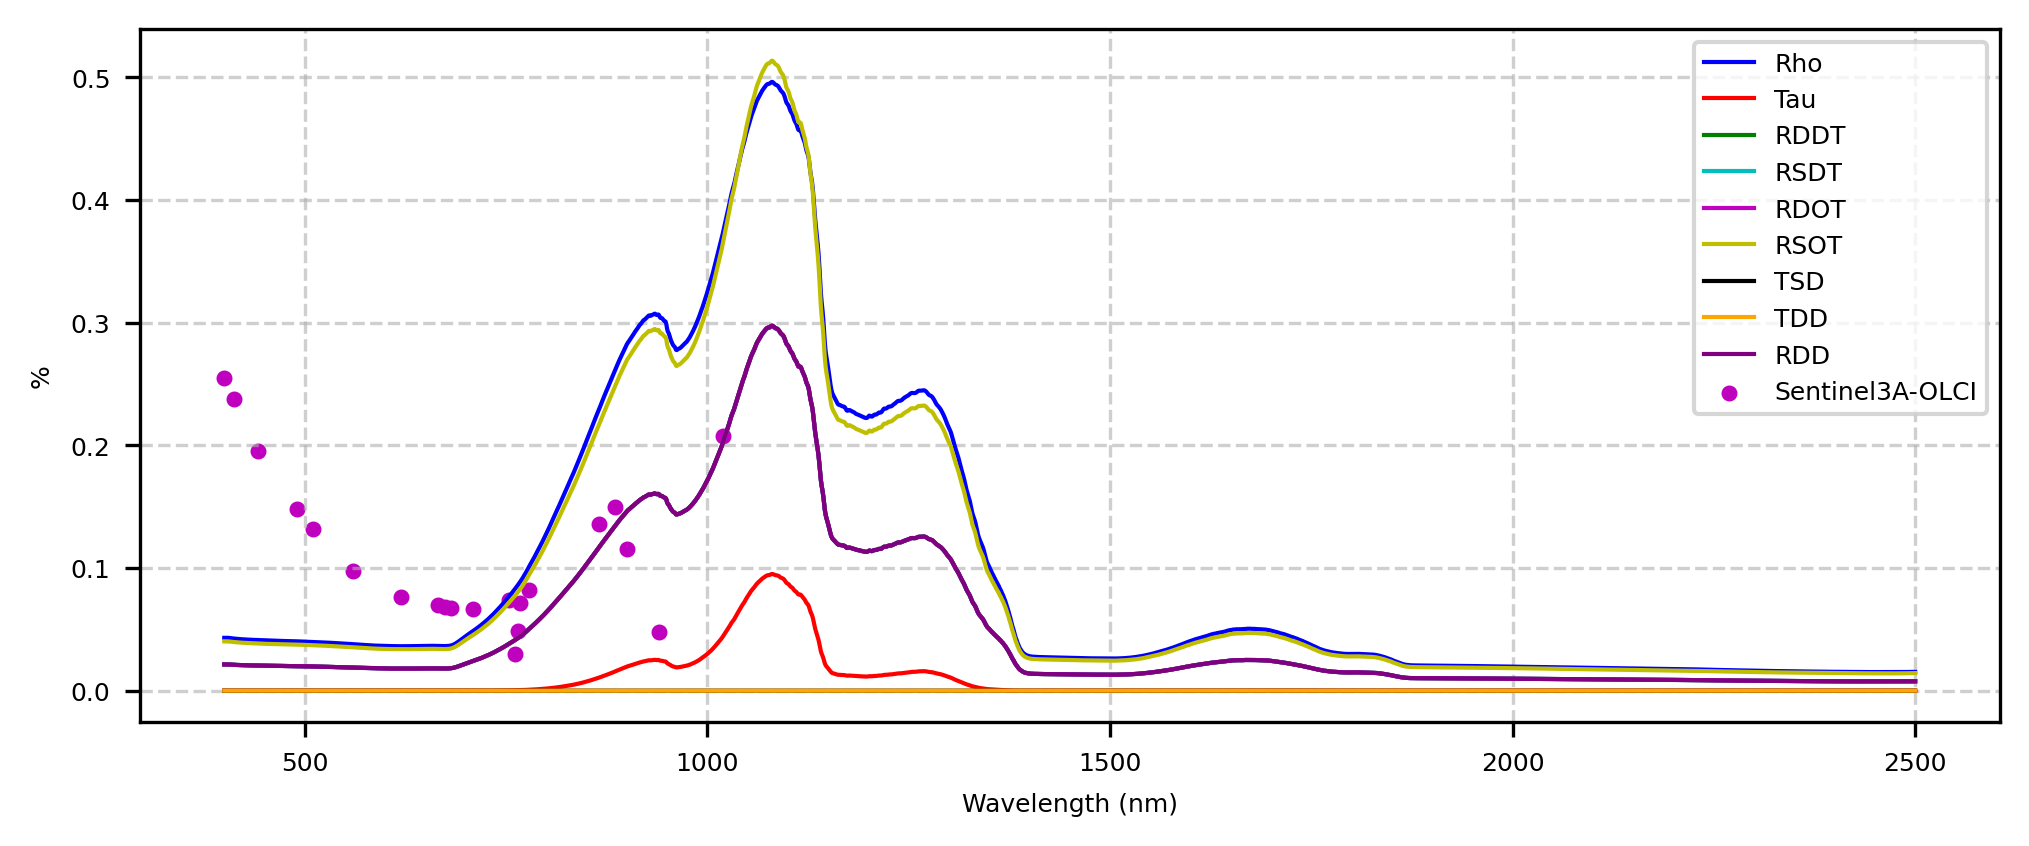

In [26]:
sensor_list = names

plt.figure(figsize=(8, 3), dpi=300)


wavelengths = np.arange(400, 2501)
# create the figure
plt.plot(wavelengths, to_np(rho[0]), label='Rho', color='b', linewidth=1)
plt.plot(wavelengths, to_np(tau[0]), label='Tau', color='r', linewidth=1)
plt.plot(wavelengths, to_np(rddt[0]), label='RDDT', color='g', linewidth=1)
plt.plot(wavelengths, to_np(rsdt[0]), label='RSDT', color='c', linewidth=1)
plt.plot(wavelengths, to_np(rdot[0]), label='RDOT', color='m', linewidth=1)
plt.plot(wavelengths, to_np(rsot[0]), label='RSOT', color='y', linewidth=1)
plt.plot(wavelengths, to_np(tsd[0]), label='TSD', color='k', linewidth=1)
plt.plot(wavelengths, to_np(tdd[0]), label='TDD', color='orange', linewidth=1)
plt.plot(wavelengths, to_np(rdd[0]), label='RDD', color='purple', linewidth=1)

plt.grid(True, linestyle='--', alpha=0.6)
for _ in [1]:
  plt.scatter(toa_results[_][0], (toa_results[_][1][0].detach().cpu().numpy()), color='m', label=sensor_list[_].split('.')[0],s = 8)

plt.tick_params(axis='both', labelsize=6)

plt.xlabel('Wavelength (nm)', fontsize=6)
plt.ylabel('%', fontsize=6)
plt.legend(fontsize=6)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Visulaize the TOA based on all supported snesors in TorchRTM

# Translation Fidelity: Verifying Consistency with Legacy RTMs

The fin al section evaluates the goal of this document: how closely TorchRTM reproduces the outputs of the established Fortran and MATLAB implementations of PROSPECT, PROSAIL and SMAC.

NOte that because TorchRTM introduces a much higher level of abstraction with amongs others: GPU acceleration, differentiability, parallelization - this is typically more than simply a refactoring to a modern software language.  Therefore, we demonstrate that these enhancements do not alter the underlying physical behaviour of the models.

The code provided here serves as a display of how we verified all modules. It compares TorchRTM's forward simulations with the outputs generated by the original Fortran/MATLAB versions under identical parameter settings. We then test using some standard statistics that TorchRTM maintains numerical and physical consistency with the legacy models it is designed to extend.


### Dependencies
Because the legacy PROSPECT-SAIL and SMAC codes must be executed through their native Fortran/MATLAB environments, the examples below require those dependencies to be installed and linked externally. **The original fortran codes used here are available from the lead author Peng Sun upon request - but are also published and publically available elsewhere.**

## Workflow:

- Compile and load the legacy Fortran version of PROSPECT5B + 4SAIL.

- Generate identical input parameters for both TorchRTM and the legacy code.

- Run forward simulations in both systems, extract key spectral variables, and align outputs.

- Produce diagnostic plots and R² statistics to quantify the match between implementations.

- Repeat the test across multiple random parameter sets to ensure robustness.

Together these steps provide a minimal demonstration that TorchRTM preserves the scientific integrity of PROSPECT, PROSAIL, and SMAC.

### Prospect5d + 4sail

Set up the specific dependancies for Fortran Programe

In [33]:
import sys
import os
sys.path.append('/home/cml/Documents/simulator/pre_tran')
os.chdir('/home/cml/Documents/simulator/pre_tran')
os.listdir()
os.system('bash /home/cml/Documents/simulator/pre_tran/complie.sh')

0

The **MAIN** function establishes the link between TorchRTM and the Fortran version (**PROSPECT5B+4SAIL**).

In [36]:

def test_for_prosail(N,Cab,Car,Cbrown,Cw,Cm,LAI,hspot,tts,tto,psi):


  numiters=1
  cputimeflag=0  # 1 call cpu_time to compute computation time; 0 call date_and_time
  typelidf=2
  psoil=0.1

  title = (
      "Simulation vs. Reference Results for PROSAIL\n"
      f"N={N:.3f}, Cab={Cab:.3f}, Car={Car:.3f}, Cbrown={Cbrown:.3f}, Cw={Cw:.3f}, Cm={Cm:.3f}\n"
      f"LAI={LAI:.3f}, hspot={hspot:.3f}, tts={tts:.3f}, tto={tto:.3f}, psi={psi:.3f}, psoil={psoil:.3f}"
  )



  with open('para.ini','w') as f:
    f.write("{} {} {} {}\n".format(numiters,cputimeflag,typelidf,psoil))
    f.write("{} {} {} {} {} {}\n".format(Cab,Car,Cbrown,Cw,Cm,N))
    f.write("{} {} {} {} {}\n".format(LAI,hspot,tts,tto,psi))
  os.system('./executable.exe')

  device = torch.device("cpu") # set up the device

  matrixall=np.loadtxt('./outmatrix')


  lai = torch.tensor(LAI).unsqueeze(0)
  LIDFa = torch.tensor(30).unsqueeze(0)
  LIDFb = torch.tensor(0).unsqueeze(0)
  q = torch.tensor(hspot).unsqueeze(0)
  tts = torch.tensor(tts).unsqueeze(0)
  tto = torch.tensor(tto).unsqueeze(0)
  psi = torch.tensor(psi).unsqueeze(0)
  psoil = torch.tensor(psoil).unsqueeze(0)
  N = torch.tensor(N).unsqueeze(0)
  Cab = torch.tensor(Cab).unsqueeze(0)
  Car =torch.tensor(Car).unsqueeze(0)
  Cbrown = torch.tensor(Cbrown).unsqueeze(0)
  Cw = torch.tensor(Cw).unsqueeze(0)
  Cm = torch.tensor(Cm).unsqueeze(0)
  #Canth = torch.tensor(0).unsqueeze(0)
  alpha = torch.tensor(40).unsqueeze(0)

  traits = torch.stack([Cab,Car,Cbrown,Cw,Cm]).T#.unsqueeze(0)
  rho,tau = prospect5b(traits,N, alpha = alpha,print_both = True)
  #toc = prosail(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,alpha,psoil,prospectd = False,lidtype = 2,batch_size = 5000)
  toc = prosail(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,alpha,psoil,batch_size=5000,prospect_type='prospect5b',lidtype=2)
  #print(rho.shape,toc.shape)
  torch_a = to_np(torch.concat([rho.detach().cpu(),tau.detach().cpu(),(toc[:,:,0])],axis = 0))
  print_index = []
  variables = [
      "ii", "m(ii)", "m2(ii)", "att(ii)", "sigb(ii)", "rinf(ii)", "tso(ii)",
      "tsd(ii)", "tdd(ii)", "tdo(ii)", "rsd(ii)", "rdd(ii)", "rso(ii)", "rdo(ii)",
      "rsos(ii)", "rsod(ii)", "rddt(ii)", "rsdt(ii)", "rdot(ii)", "rsodt(ii)",
      "rsost(ii)", "rsot(ii)", "rho(ii)","tau(ii)"
  ]

  # target labels
  target_variables = ["rho","tau","rddt", "rsdt", "rdot", "rsot", "tsd", "tdd"]
  print_index = []
  # find out the indicator index
  for target in target_variables:
      for idx, var in enumerate(variables):
          if target in var:
              print_index.append(idx)
              #print(target,idx)

  #for i in range(8):
      #print('the r2 of %s is %s'%(target_variables[i],r2_score((torch_a[i]),matrixall[:,print_index[i]]) ))
  name_list = ["RHO","TAU","RDDT", "RSDT", "RDOT", "RSOT", "TSD", "TDD"]

  # set up the figure frame
  fig, axes = plt.subplots(2, 4, figsize=(20, 10))
  axes = axes.flat
  for i in range(8):

      x = (torch_a[i])
      y = matrixall[:, print_index[i]]



      r2 = r2_score(y, x)

      # plot both regression line and the scatters
      sns.regplot(x=x, y=y, ax=axes[i])

      axes[i].set_aspect('equal', 'box')

      # show out the e2
      axes[i].text(0.95, 0.05, f'R² = {r2:.2f}', transform=axes[i].transAxes,
                  ha='right', va='bottom', fontsize=18)


      axes[i].set_title(name_list[i], fontsize=22)


  fig.text(0.5, -0.01, 'TorchRTM', ha='center', va='center', fontsize=24)
  fig.text(-0.003, 0.5, 'Fortran', ha='center', va='center', rotation='vertical', fontsize=24)


  fig.suptitle(title, fontsize=18)

  plt.tight_layout(rect=[0, 0.1, 1, 1])  #

  plt.show()

In [42]:

def test_for_prosail(N,Cab,Car,Cbrown,Cw,Cm,LAI,hspot,tts,tto,psi):


    numiters=1
    cputimeflag=0  # 1 call cpu_time to compute computation time; 0 call date_and_time
    typelidf=2
    psoil=0.1
    title = (
        "Simulation vs. Reference Results for PROSAIL\n"
        f"N={N:.3f}, Cab={Cab:.3f}, Car={Car:.3f}, Cbrown={Cbrown:.3f}, Cw={Cw:.3f}, Cm={Cm:.3f}\n"
        f"LAI={LAI:.3f}, hspot={hspot:.3f}, tts={tts:.3f}, tto={tto:.3f}, psi={psi:.3f}, psoil={psoil:.3f}"
    )
    
    
    
    with open('para.ini','w') as f:
      f.write("{} {} {} {}\n".format(numiters,cputimeflag,typelidf,psoil))
      f.write("{} {} {} {} {} {}\n".format(Cab,Car,Cbrown,Cw,Cm,N))
      f.write("{} {} {} {} {}\n".format(LAI,hspot,tts,tto,psi))
    os.system('./executable.exe')
    
    device = torch.device("cpu") # set up the device
    
    matrixall=np.loadtxt('./outmatrix')
    
    
    lai = torch.tensor(LAI).unsqueeze(0).cuda()
    LIDFa = torch.tensor(30).unsqueeze(0).cuda()
    LIDFb = torch.tensor(0).unsqueeze(0).cuda()
    q = torch.tensor(hspot).unsqueeze(0).cuda()
    tts = torch.tensor(tts).unsqueeze(0).cuda()
    tto = torch.tensor(tto).unsqueeze(0).cuda()
    psi = torch.tensor(psi).unsqueeze(0).cuda()
    psoil = torch.tensor(psoil).unsqueeze(0).cuda()
    N = torch.tensor(N).unsqueeze(0).cuda()
    Cab = torch.tensor(Cab).unsqueeze(0).cuda()
    Car =torch.tensor(Car).unsqueeze(0).cuda()
    Cbrown = torch.tensor(Cbrown).unsqueeze(0).cuda()
    Cw = torch.tensor(Cw).unsqueeze(0).cuda()
    Cm = torch.tensor(Cm).unsqueeze(0).cuda()
    #Canth = torch.tensor(0).unsqueeze(0)
    alpha = torch.tensor(40).unsqueeze(0).cuda()
    
    traits = torch.stack([Cab,Car,Cbrown,Cw,Cm]).T#.unsqueeze(0)
    rho,tau = prospect5b(traits,N, alpha = alpha,print_both = True)
    toc = prosail(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,alpha,psoil,prospect_type = 'prospect5b',lidtype = 2,batch_size = 5000)
    #print(rho.shape,toc.shape)
    torch_a = to_np(torch.concat([rho.detach().cpu(),tau.detach().cpu(),(toc[:,:,0])],axis = 0))
    print_index = []
    variables = [
        "ii", "m(ii)", "m2(ii)", "att(ii)", "sigb(ii)", "rinf(ii)", "tso(ii)",
        "tsd(ii)", "tdd(ii)", "tdo(ii)", "rsd(ii)", "rdd(ii)", "rso(ii)", "rdo(ii)",
        "rsos(ii)", "rsod(ii)", "rddt(ii)", "rsdt(ii)", "rdot(ii)", "rsodt(ii)",
        "rsost(ii)", "rsot(ii)", "rho(ii)","tau(ii)" , "tsstoo","sumint","tss"," too","w","lai","rdd(ii)","ddb"," ddf","sdb"," sdf","dob","dof","ks"," ko","sob"," sof","tts"," tto"," cts"," cto"," psi"," ctscto","lidf(ii)"
    ]
    # target labels
    target_variables = ["rho","tau","rddt", "rsdt", "rdot", "rsost", "tsd", "tdd"]
    target_variables = ["rho","tau","rddt", "rsdt", "rdot", "rsot", "tsd", "tdd"]
    
    print_index = []
    # find out the indicator index
    for target in target_variables:
        for idx, var in enumerate(variables):
            if target in var:
                print_index.append(idx)
                #print(target,idx)
    
    #for i in range(8):
        #print('the r2 of %s is %s'%(target_variables[i],r2_score((torch_a[i]),matrixall[:,print_index[i]]) ))
    name_list = ["RHO","TAU","RDDT", "RSDT", "RDOT", "RSOT", "TSD", "TDD"]
    
    # set up the figure frame
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flat
    for i in range(8):
    
        x = (torch_a[i])
        y = matrixall[:, print_index[i]]
    
    
    
        r2 = r2_score(y, x)
    
        # plot both regression line and the scatters
        axes[i].scatter(x=x, y=y)
    
        axes[i].set_aspect('equal', 'box')
    
        # show out the e2
        axes[i].text(0.95, 0.05, f'R² = {r2:.2f}', transform=axes[i].transAxes,
                    ha='right', va='bottom', fontsize=18)
    
    
        axes[i].set_title(name_list[i], fontsize=22)
    
    
    fig.text(0.5, -0.01, 'TorchRTM', ha='center', va='center', fontsize=24)
    fig.text(-0.003, 0.5, 'Fortran', ha='center', va='center', rotation='vertical', fontsize=24)
    
    
    fig.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0.1, 1, 1])  #
    
    plt.show()

Run the translation test for 10 test with the random input parameters

_____________________________0 time______________________
 TypeLidf:           2
   41.230462154021751        7.9760566202203647        8.7809719511921787E-004   1.0889808461046022E-002   8.2107805047870793E-003   4.0042193489683076     
   2.4291791597177448        1.0581889183628670E-002   26.125328152884588        11.761834337411656       0.11815714308010349     
 date: 20260106 time1: 143119.470 time2: 143119.471
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


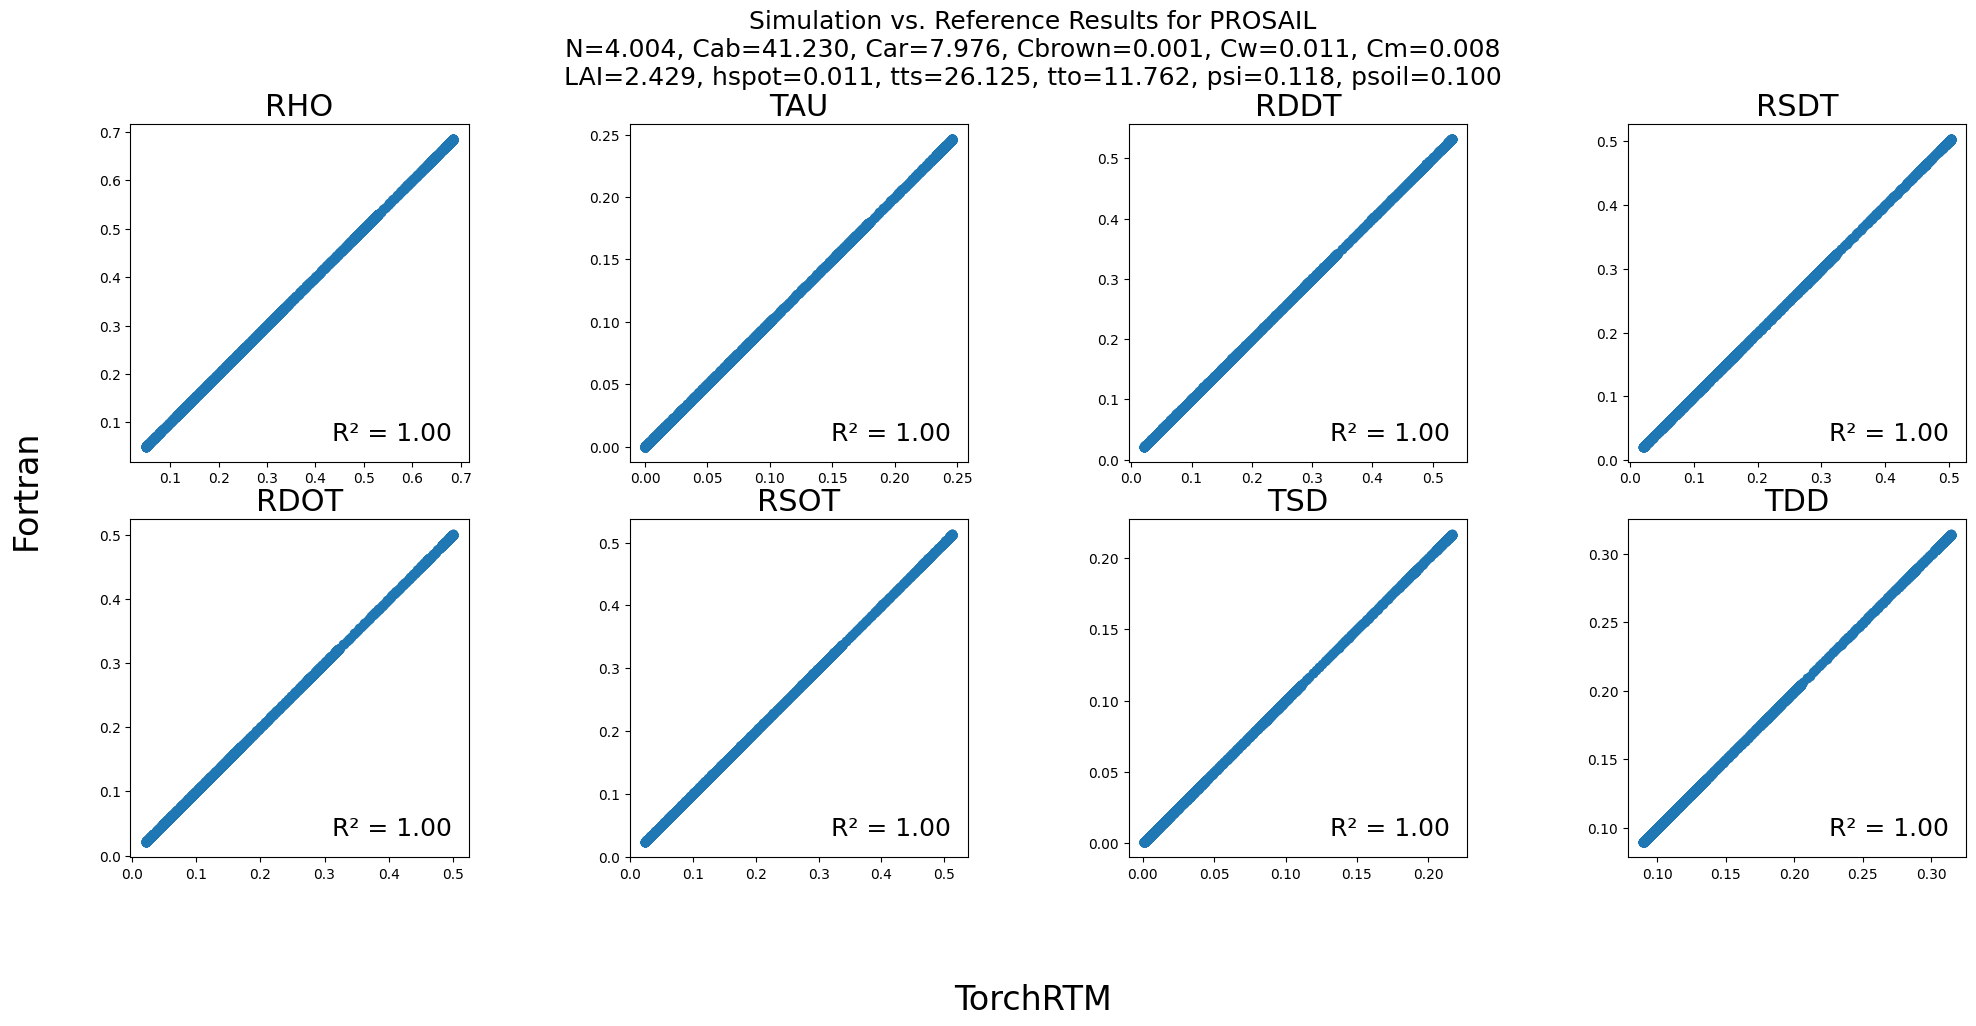

_____________________________1 time______________________
 TypeLidf:           2
   37.922539204087109        6.4494611728923763        1.1713274250350900E-003   9.7127365932692580E-003   1.0679957348557208E-002   4.6637830243527176     
   3.5563439725071029        1.1412037821869440E-002   27.533386704835028        9.5403909144077019       0.11404546686067428     
 date: 20260106 time1: 143122.826 time2: 143122.827
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


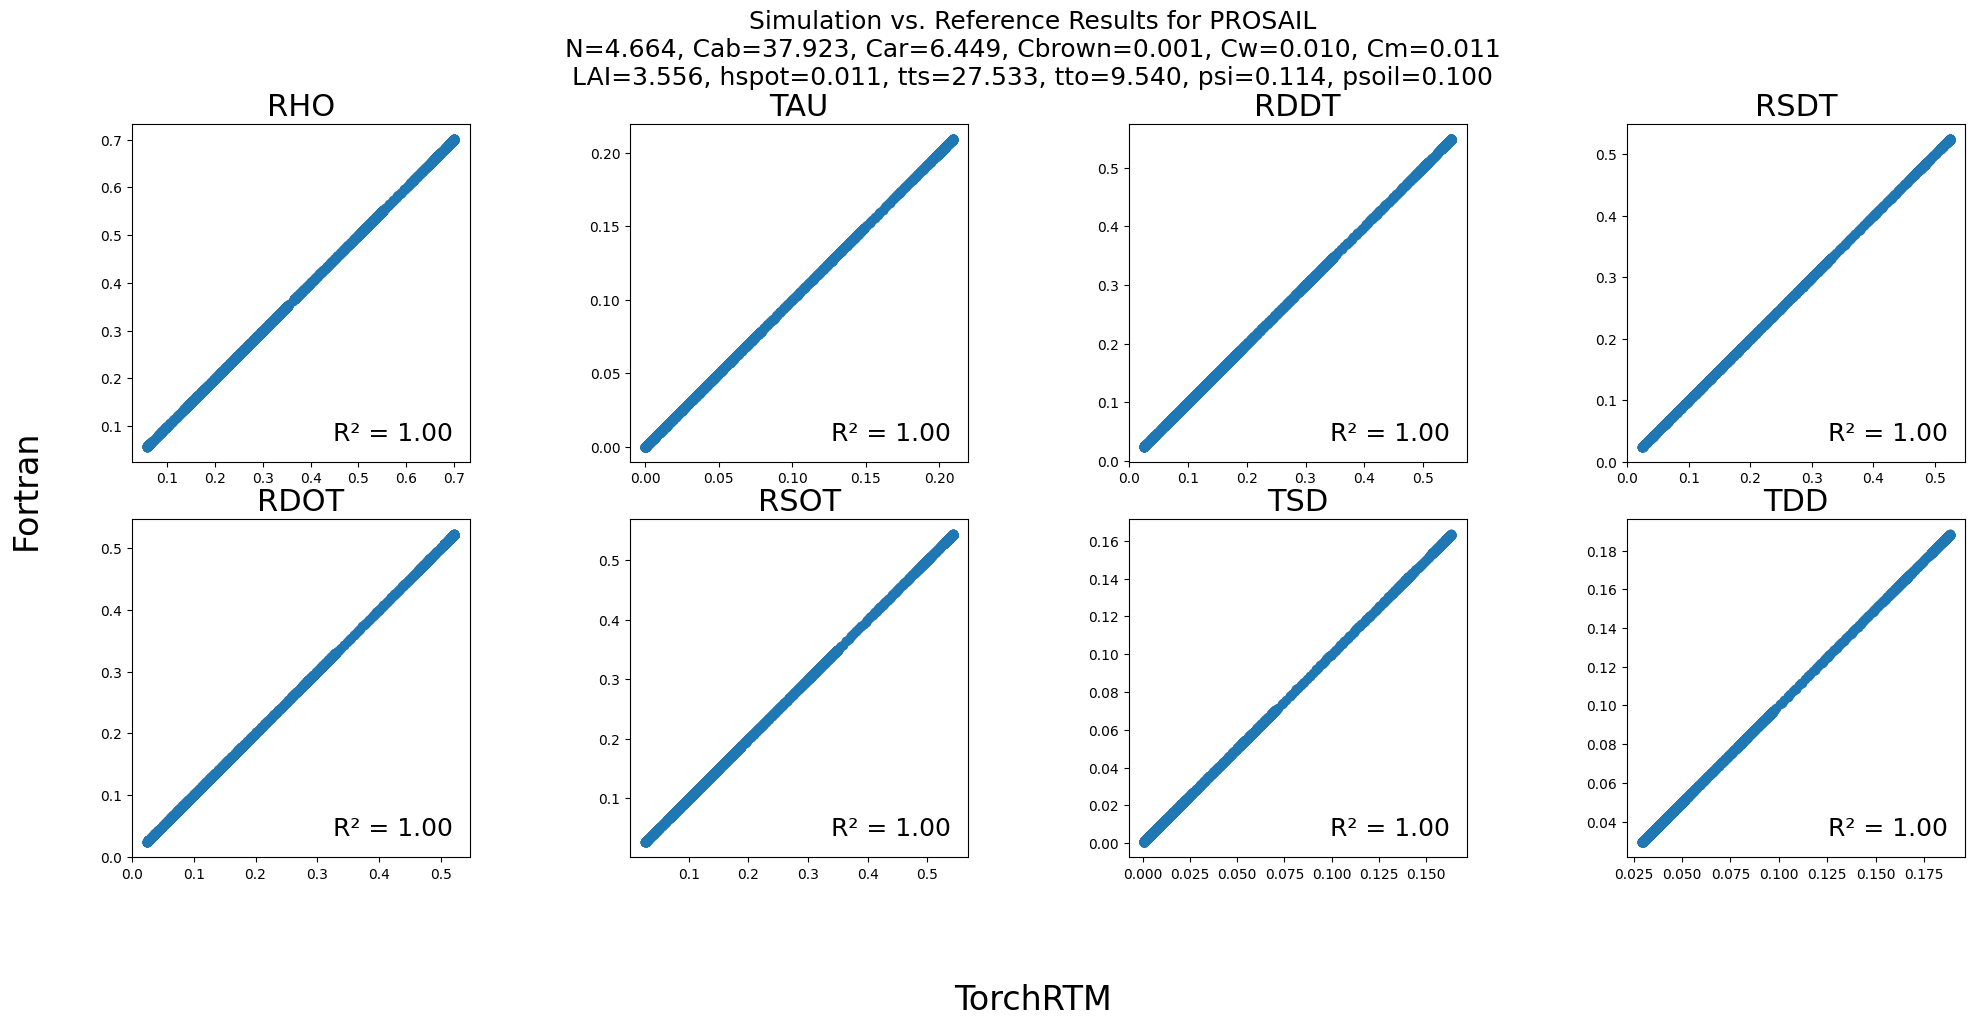

_____________________________2 time______________________
 TypeLidf:           2
   34.711883946977480        8.1817640398667209        1.1744619096643123E-003   1.0784119186699892E-002   9.2522202123217125E-003   3.7070752082500444     
   2.5166117925249223        1.0460028906796679E-002   35.880646201251153        8.5603360609460957       0.10073318609454947     
 date: 20260106 time1: 143126.341 time2: 143126.342
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


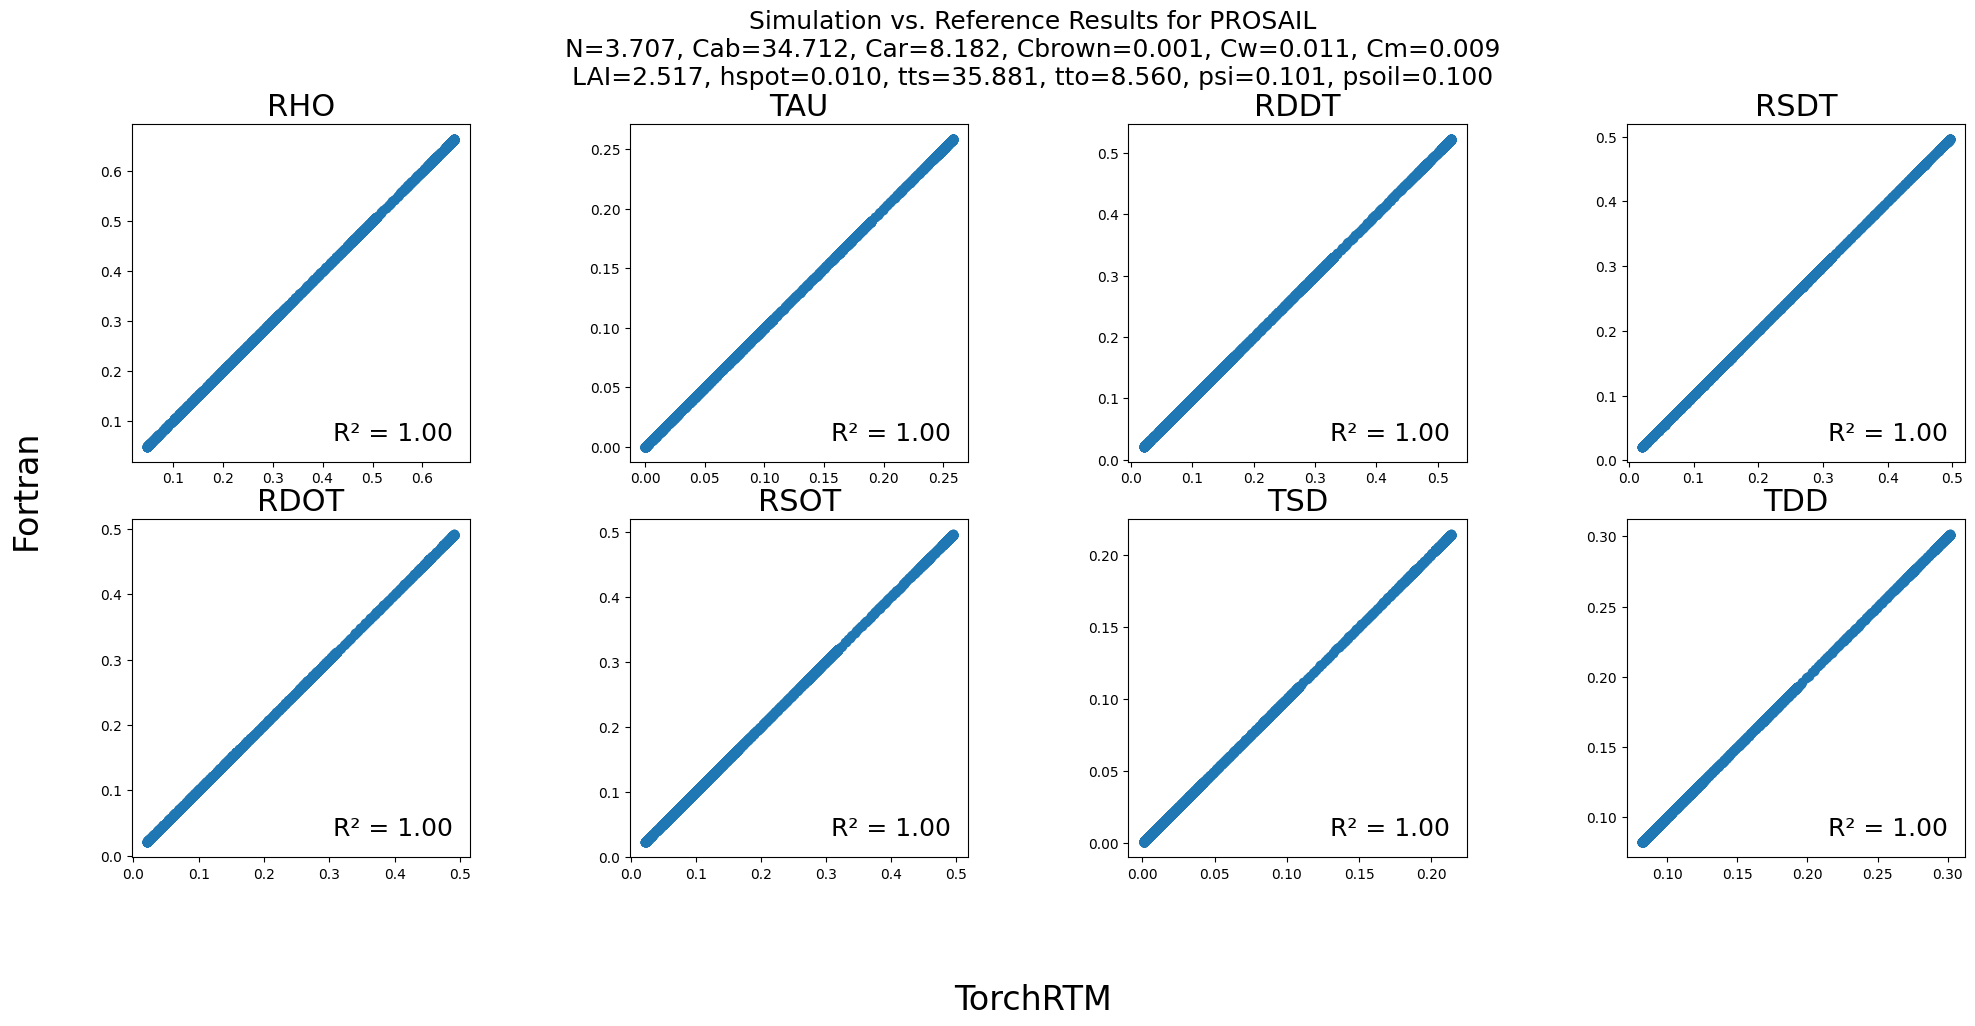

_____________________________3 time______________________
 TypeLidf:           2
   43.852297884067269        8.6304503711848568        1.0809936335948436E-003   9.4379646048790219E-003   8.2569306393521762E-003   4.6037969150847289     
   3.3712333865742163        1.1240453578716723E-002   34.404867822961251        11.652962210225885       0.10045369595443752     
 date: 20260106 time1: 143129.702 time2: 143129.703
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


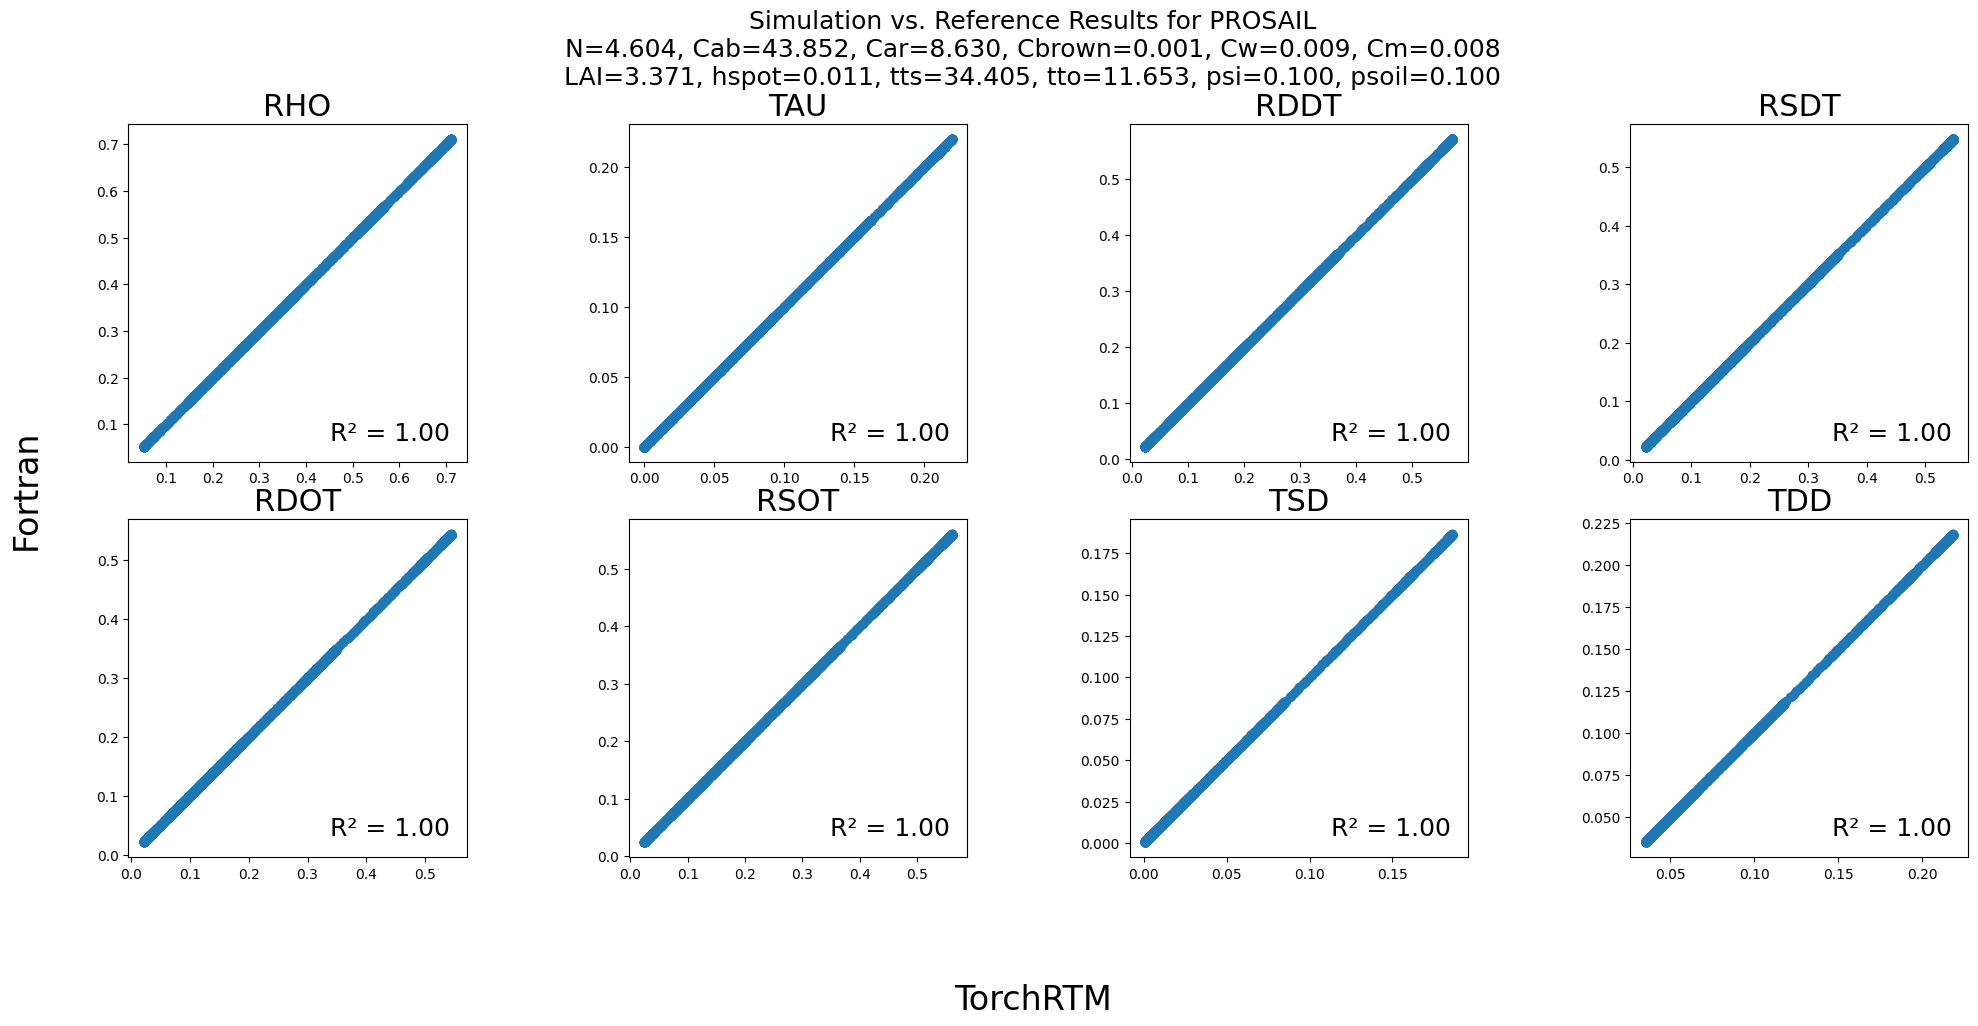

_____________________________4 time______________________
 TypeLidf:           2
   44.772722863468402        8.4798845784888481        1.0807867509030813E-003   1.1183170677744405E-002   1.0404019230543238E-002   4.0024260714995190     
   2.8055941882218431        9.5023318105597766E-003   25.127783278090430        10.313120563984697        8.1437690951869701E-002
 date: 20260106 time1: 143133.103 time2: 143133.104
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


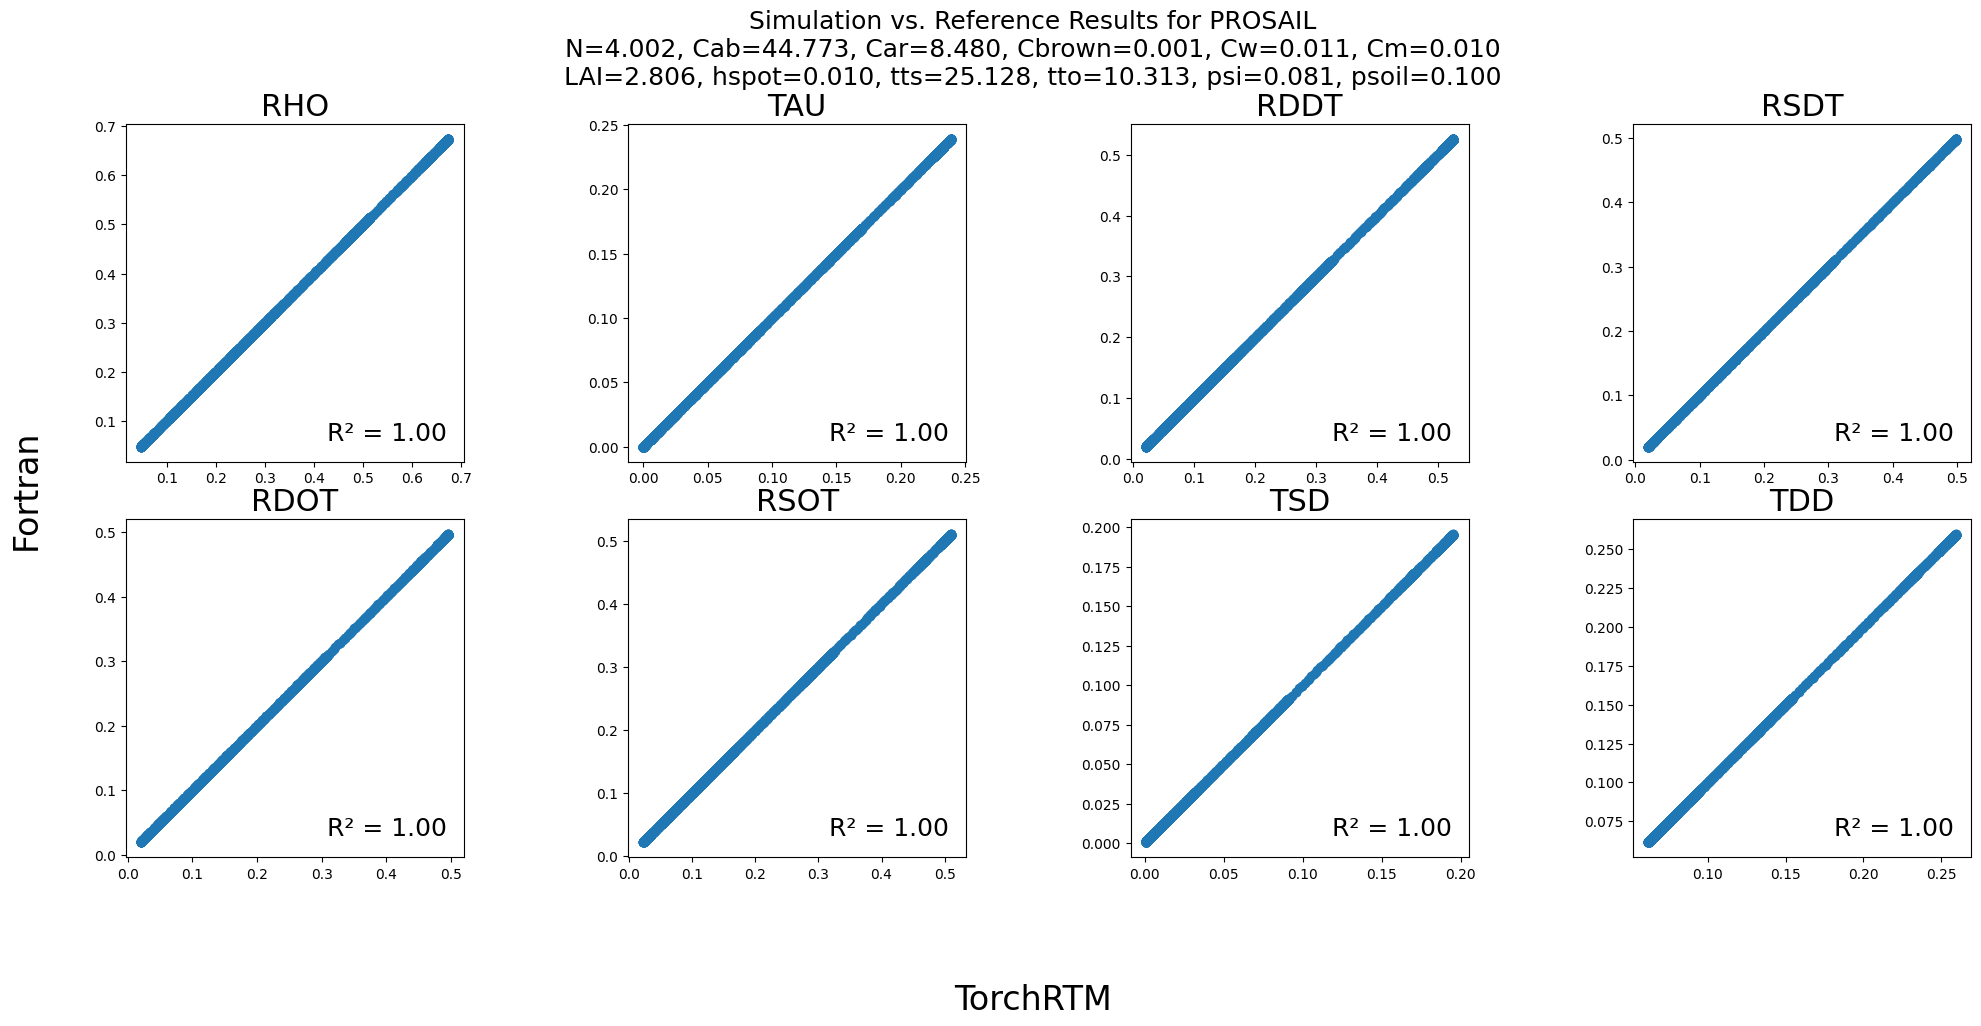

_____________________________5 time______________________
 TypeLidf:           2
   40.682314155321222        7.3169320068105099        1.0363333042276044E-003   8.1220009997561987E-003   7.3344534794971715E-003   3.9449568290119363     
   3.3871206727915899        9.4407625656450517E-003   25.524726151822620        10.088973040219217       0.11079974212394444     
 date: 20260106 time1: 143136.531 time2: 143136.532
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


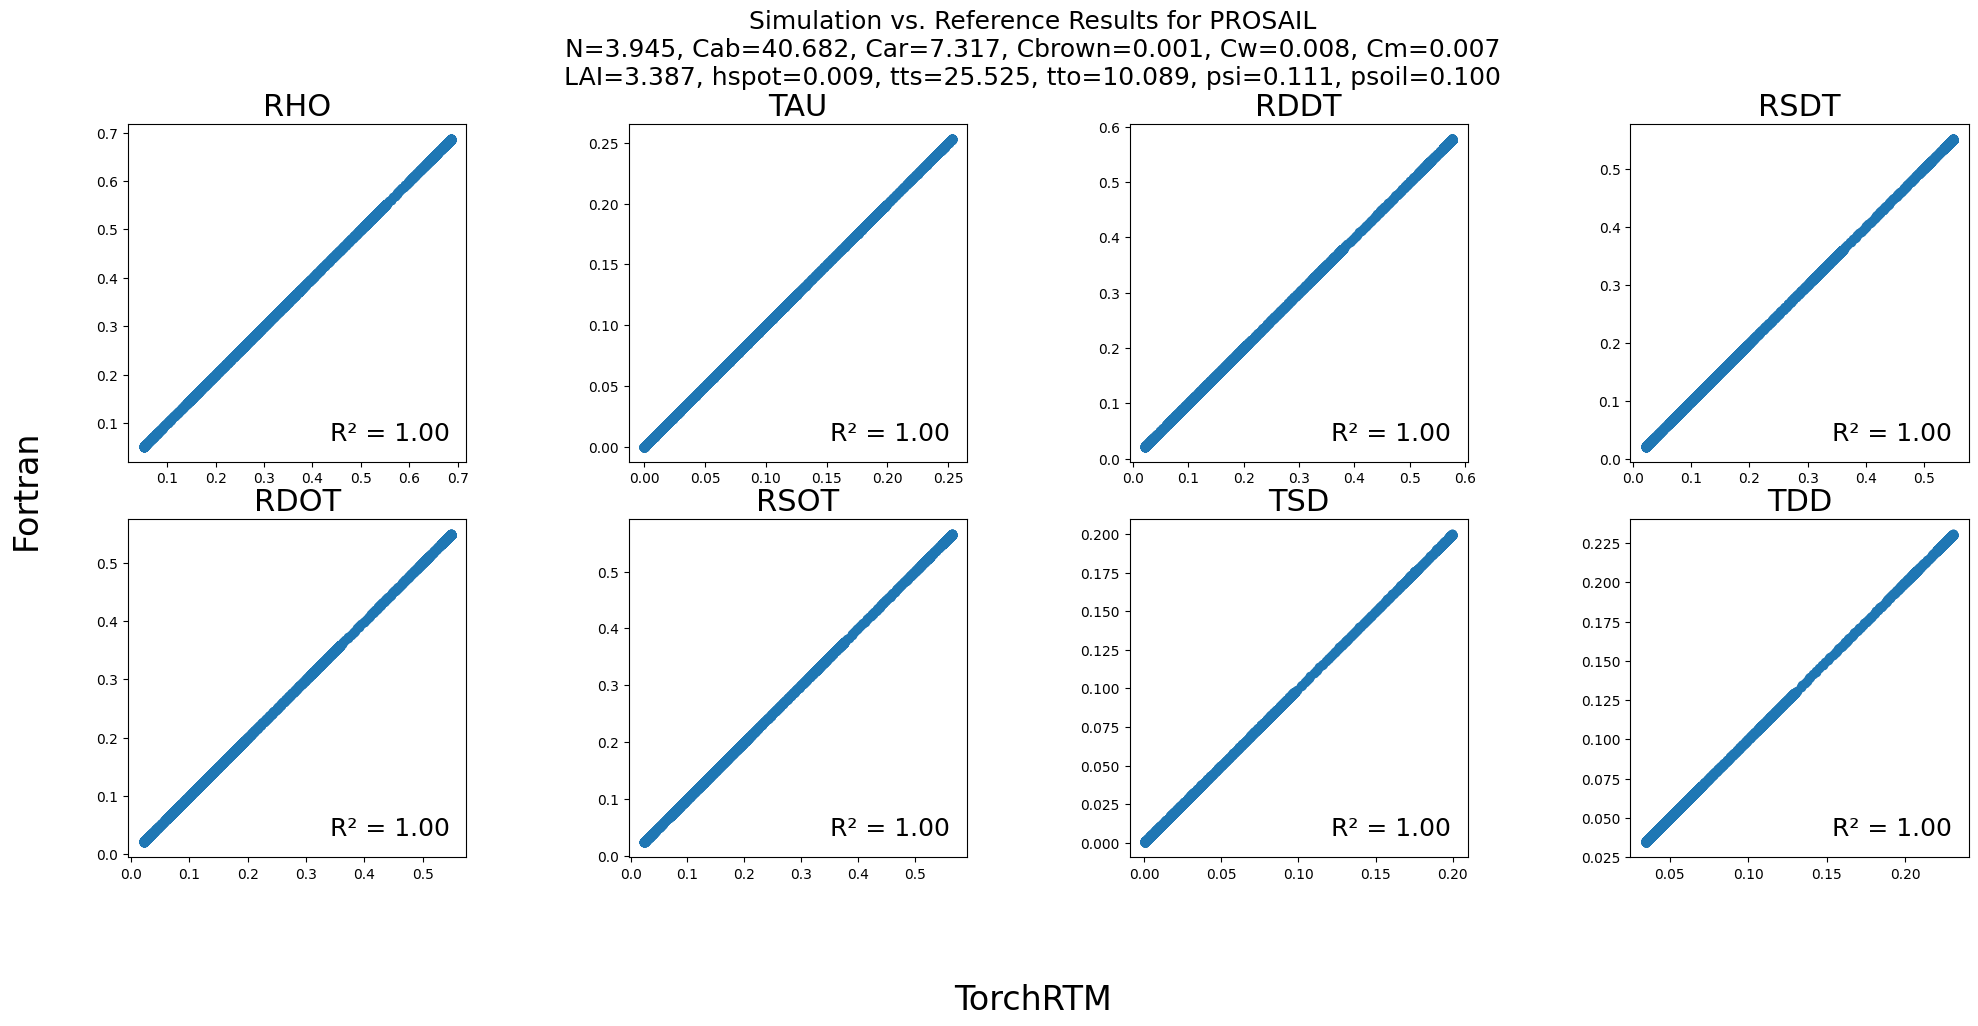

_____________________________6 time______________________
 TypeLidf:           2
   41.966247613104002        6.6731118879800579        8.2067268846744315E-004   1.0125418526272592E-002   9.1462864377963825E-003   3.5453136439949491     
   3.1649158817978478        1.0904365334890647E-002   35.710224953550409        10.065201393204781        9.2918258917649849E-002
 date: 20260106 time1: 143139.900 time2: 143139.901
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


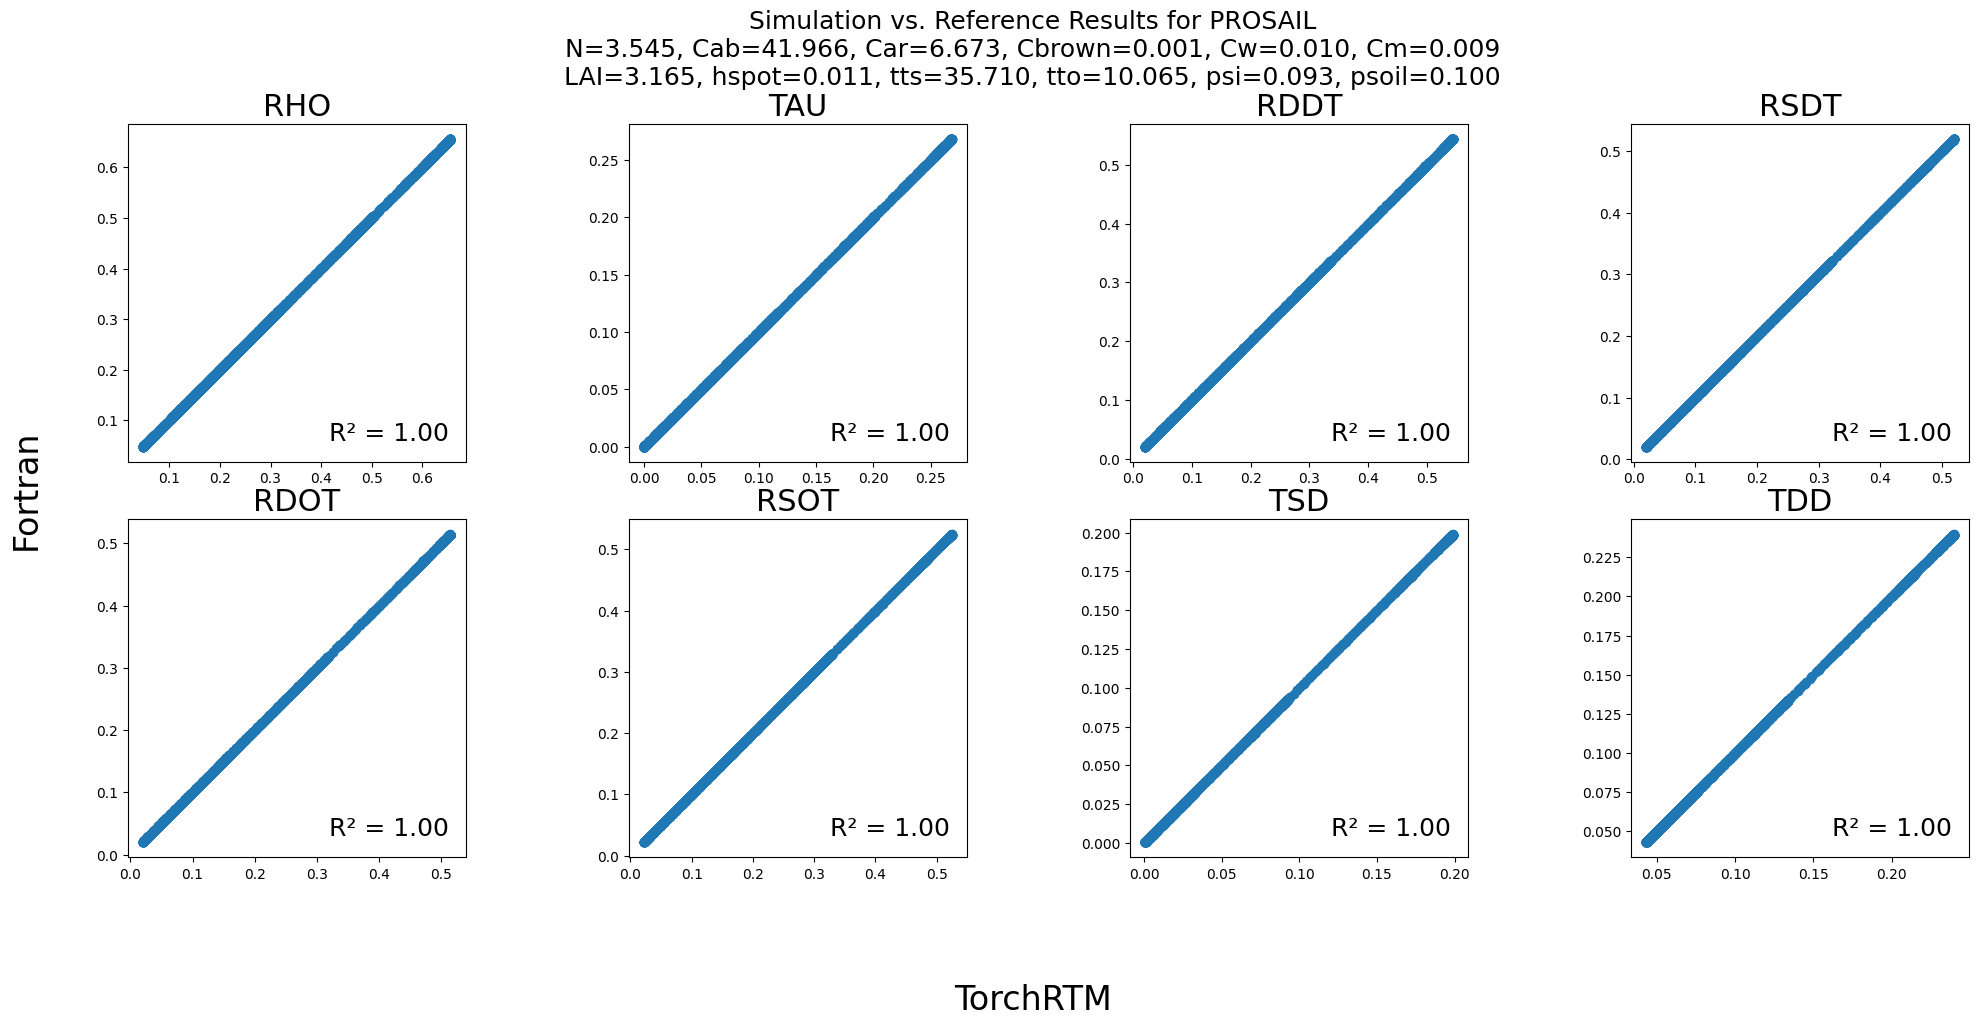

_____________________________7 time______________________
 TypeLidf:           2
   36.333316020193188        7.8047085462580359        8.3138255253690640E-004   8.1014029736618306E-003   1.0665534292840530E-002   4.4722979116299255     
   3.4031761446146471        1.0783896824374792E-002   28.907435332971239        8.6931772802833844        8.6257481706843442E-002
 date: 20260106 time1: 143143.295 time2: 143143.296
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


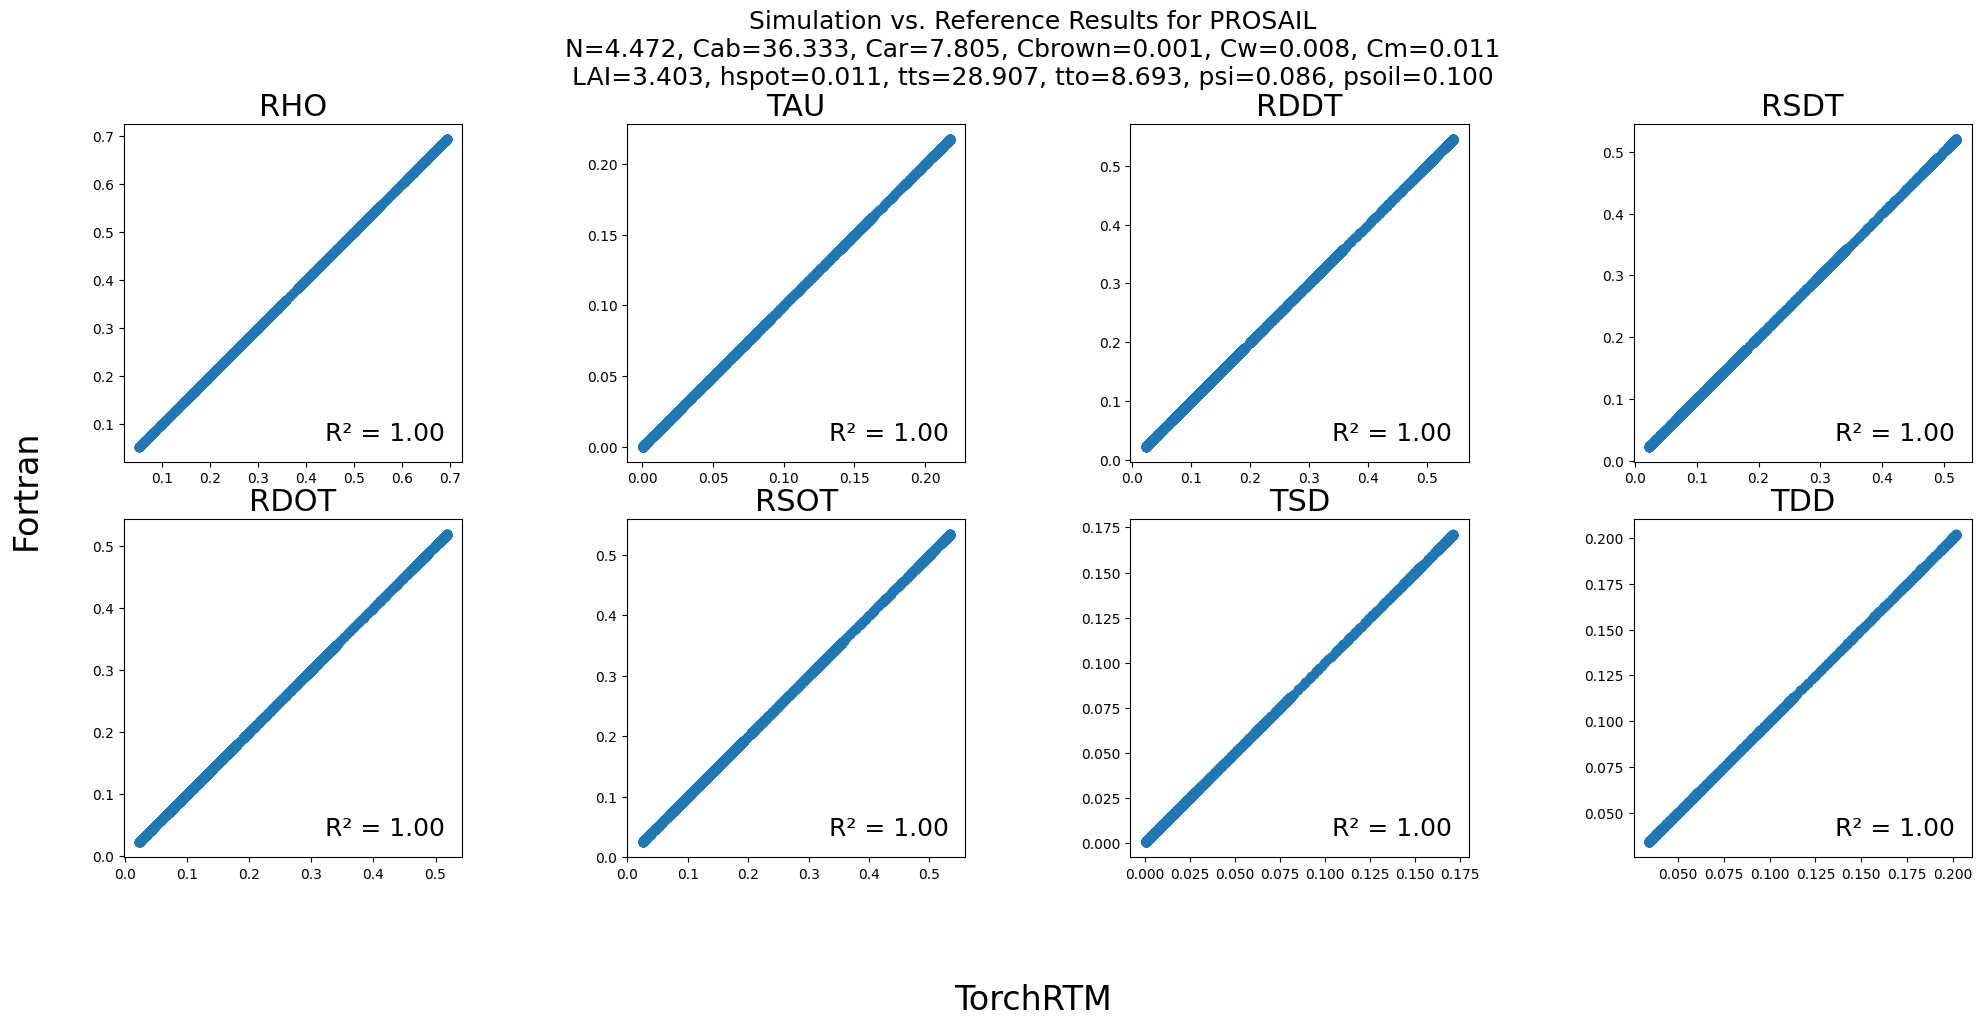

_____________________________8 time______________________
 TypeLidf:           2
   40.787626635297933        8.6867069526401988        1.0640789506870924E-003   9.1197355877837716E-003   1.0637515010387497E-002   3.6003886370633524     
   3.2854763000349223        1.0217416210045602E-002   31.340648954812227        9.6784002497111601        8.9909239580046305E-002
 date: 20260106 time1: 143146.795 time2: 143146.796
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


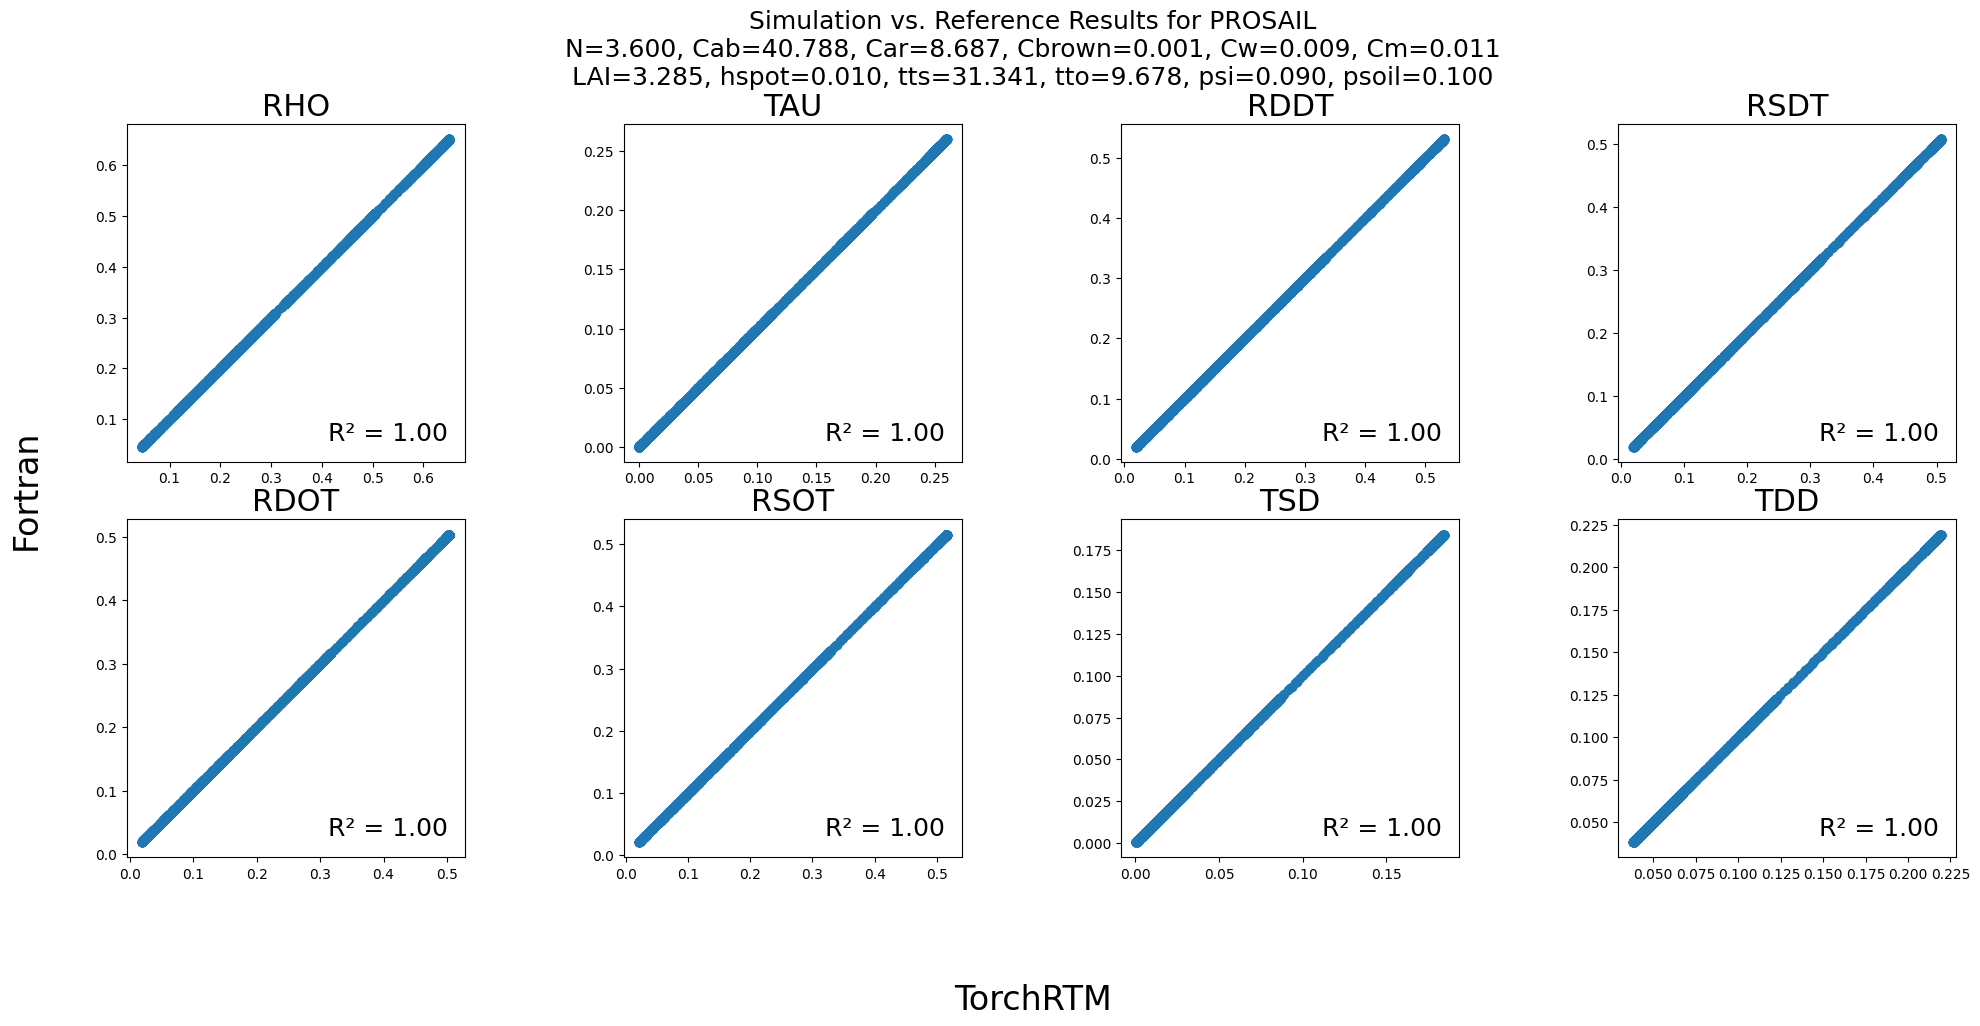

_____________________________9 time______________________
 TypeLidf:           2
   44.125537767429904        6.4460591636152191        8.4642905620276650E-004   8.1840105680870117E-003   7.3466236883482916E-003   3.7695562858420186     
   3.4265527008132084        1.0814631437520095E-002   29.690085949047901        8.3913366426040064        9.9664635004673305E-002
 date: 20260106 time1: 143150.224 time2: 143150.225
 call date_and_time:   0.00000000    
        2101


Note: The following floating-point exceptions are signalling: IEEE_DENORMAL


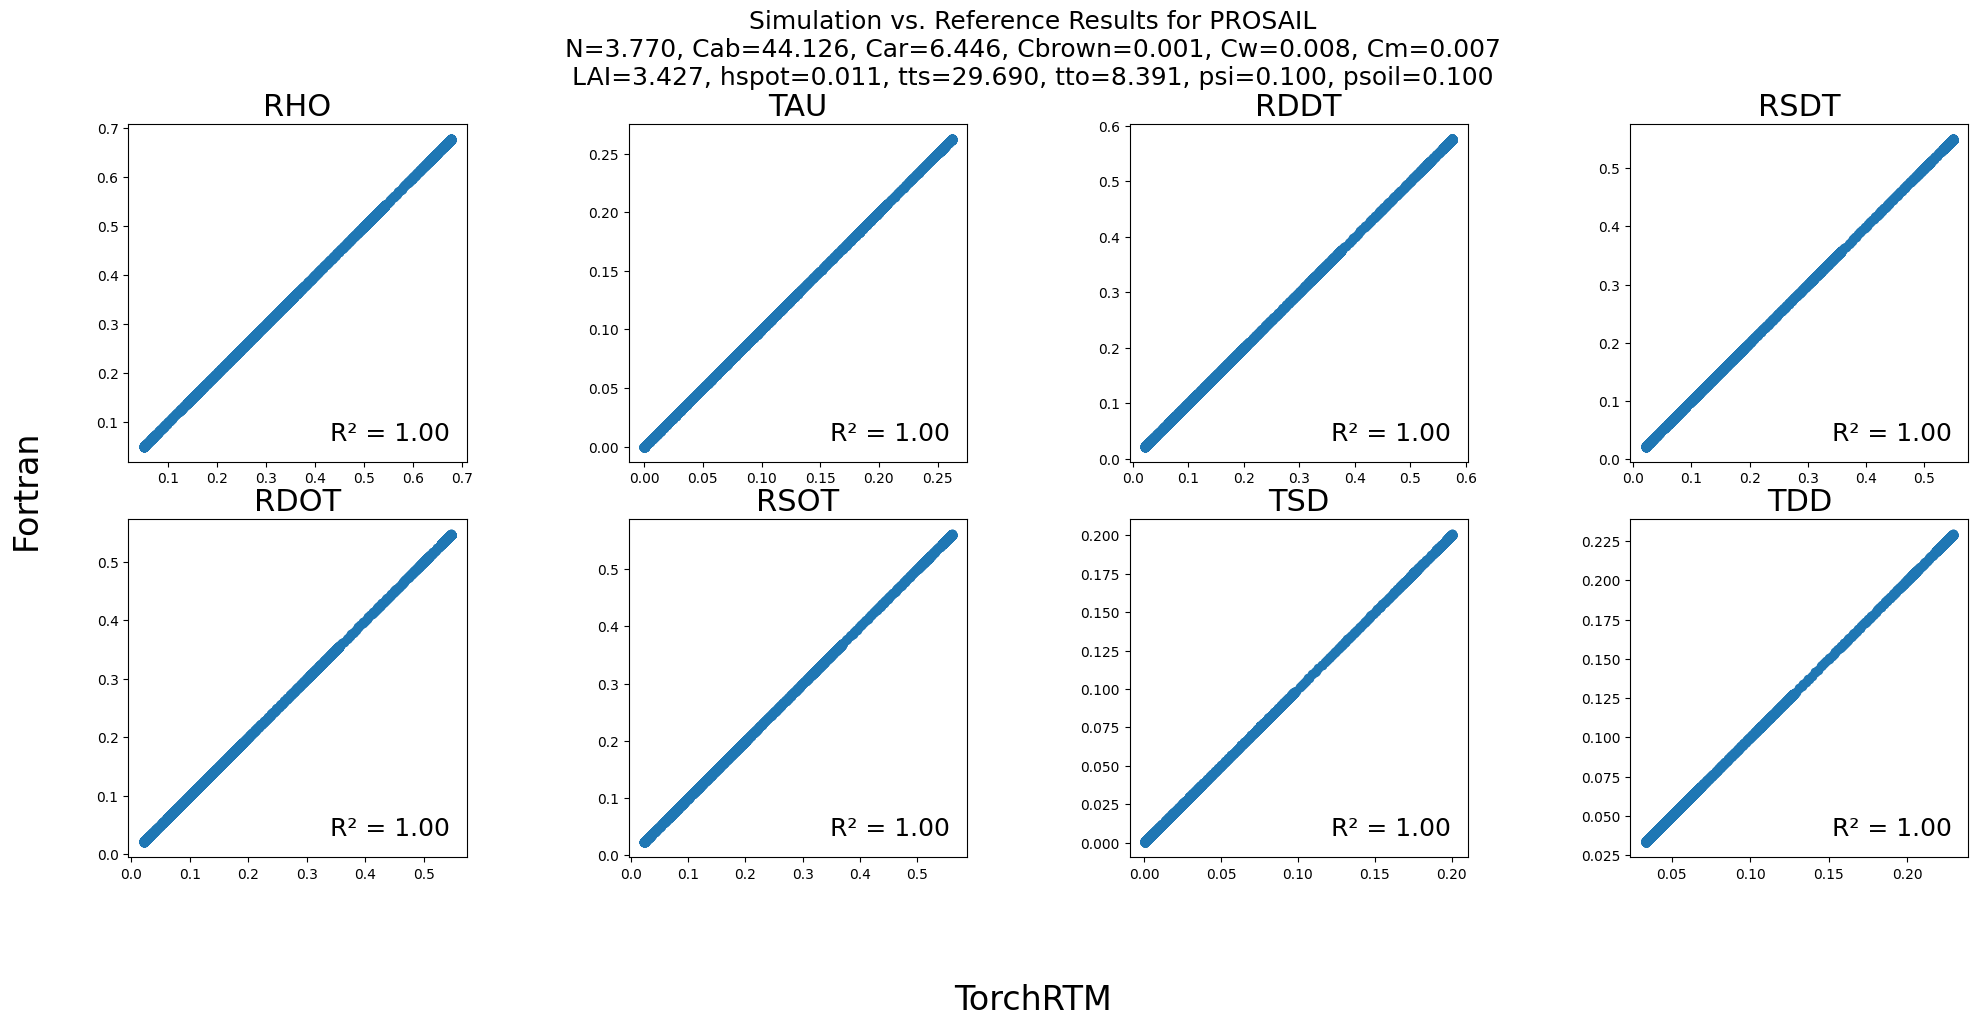

In [43]:



# inital parematers
params = {
    "N": 4, "Cab": 40., "Car": 8., "Cbrown": 0.001, "Cw": 0.01, "Cm": 0.009,
    "LAI": 3, "hspot": 0.01, "tts": 30, "tto": 10, "psi": 0.1
}


num_runs = 10

for i in range(num_runs):
    # Generate new parameters, each varying within a ±20% range.
    new_params = {key: value * np.random.uniform(0.8, 1.2) for key, value in params.items()}
    print('_____________________________%s time______________________'%i)
    # run test_for_prosail
    test_for_prosail(**new_params)


### SMAC

Set up the specific dependancies for Octave Programe

In [44]:
import scipy.io
import subprocess


The **MAIN** function establishes the link between TorchRTM and the Fortran version (**PROSPECT5B+4SAIL**).

In [45]:
def test_for_smac(tts, tto, psi, coefs):

  title = (
      "Simulation vs. Reference Results for SMAC\n"
      f"tts={tts:.3f}, tto={tto:.3f}, psi={psi:.3f}"
  )


  device = torch.device("cpu") # set up the device

  subprocess.run(["octave", "--no-window-system", "run_add.m"])

  tts = torch.tensor(tts).unsqueeze(0)
  tto = torch.tensor(tto).unsqueeze(0)
  psi = torch.tensor(psi).unsqueeze(0)

  matrixall = scipy.io.loadmat('Opt_atm_result.mat')['Opt_atm'][0][0]

  ttetas, ttetav, tg, s, atm_ref, tdir_tts, tdif_tts, tdir_ttv, tdif_ttv = smac(tts, tto, psi, coefs) #!!!!!!!!!!!

  torch_a = to_np(torch.concat([tdir_tts, tdif_tts, tdir_ttv, tdif_ttv, ttetas, ttetav, s, atm_ref],axis = 0))
  print_index = [0,1,2,3,4,5,7,8]

  name_list = ["Ta_ss","Ta_sd","Ta_oo", "Ta_do", "Ta_s", "Ta_o", "Ra_dd",'Ra_so']
  # create the figure frame
  fig, axes = plt.subplots(2, 4, figsize=(20, 10))
  axes = axes.flat

  for i in range(8):

      x = (torch_a[i])
      y = matrixall[print_index[i]][0]



      r2 = r2_score(y, x)

      # plot both regression line and the scatters
      sns.regplot(x=x, y=y, ax=axes[i])

      axes[i].set_aspect('equal', 'box')

      # show out the e2
      axes[i].text(0.95, 0.05, f'R² = {r2:.2f}', transform=axes[i].transAxes,
                  ha='right', va='bottom', fontsize=18)


      axes[i].set_title(name_list[i], fontsize=22)


  fig.text(0.5, -0.01, 'TorchRTM', ha='center', va='center', fontsize=24)
  fig.text(-0.003, 0.5, 'Matlab', ha='center', va='center', rotation='vertical', fontsize=24)


  fig.suptitle(title, fontsize=18)

  plt.tight_layout(rect=[0, 0.1, 1, 1])  #

  plt.show()

Run the translation test for 10 test with the random input parameters (simulate the parameters via Landsat-4 as an example)

In [46]:
from torchrtm.data_loader import load_smac_sensor
toa_results = []
'''
tts = torch.tensor([30.0])
tto = torch.tensor([20.0])
psi = torch.tensor([10.0])
'''
import os

from torchrtm.atmosphere.smac import toc_to_toa


#for _ in [(names[0])]:

coefs,sm_wl = load_smac_sensor('LANDSAT4-TM')



Attempting to load sensor: LANDSAT4-TM


In [48]:
#os.chdir("/content/drive/My Drive/torch_rtm")  # I will upload the data document today.

scipy.io.savemat('coef_data.mat', {'coef': coefs})

In [49]:
from torchrtm.atmosphere.smac import smac


In [51]:

!apt-get install -y octave


E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


coef_data.mat has been generated and saved!
_____________________________0 time______________________


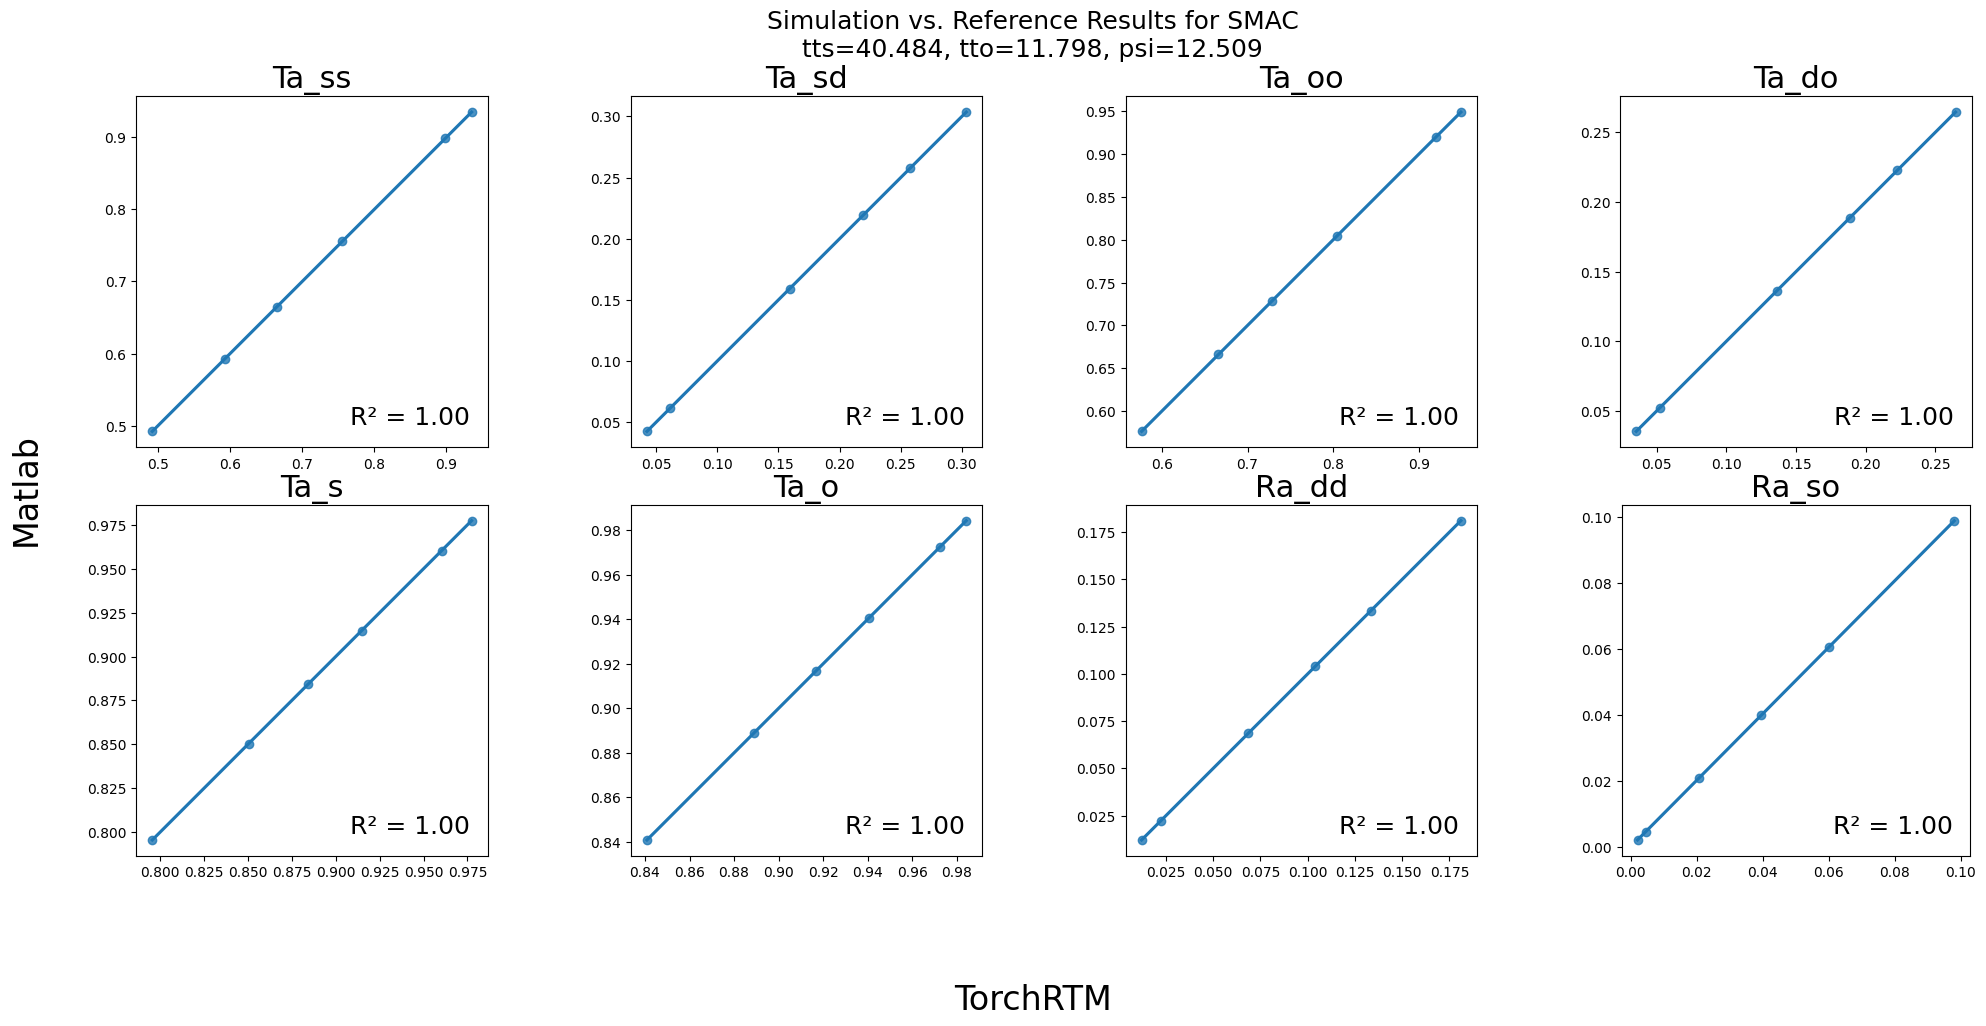

coef_data.mat has been generated and saved!
_____________________________1 time______________________


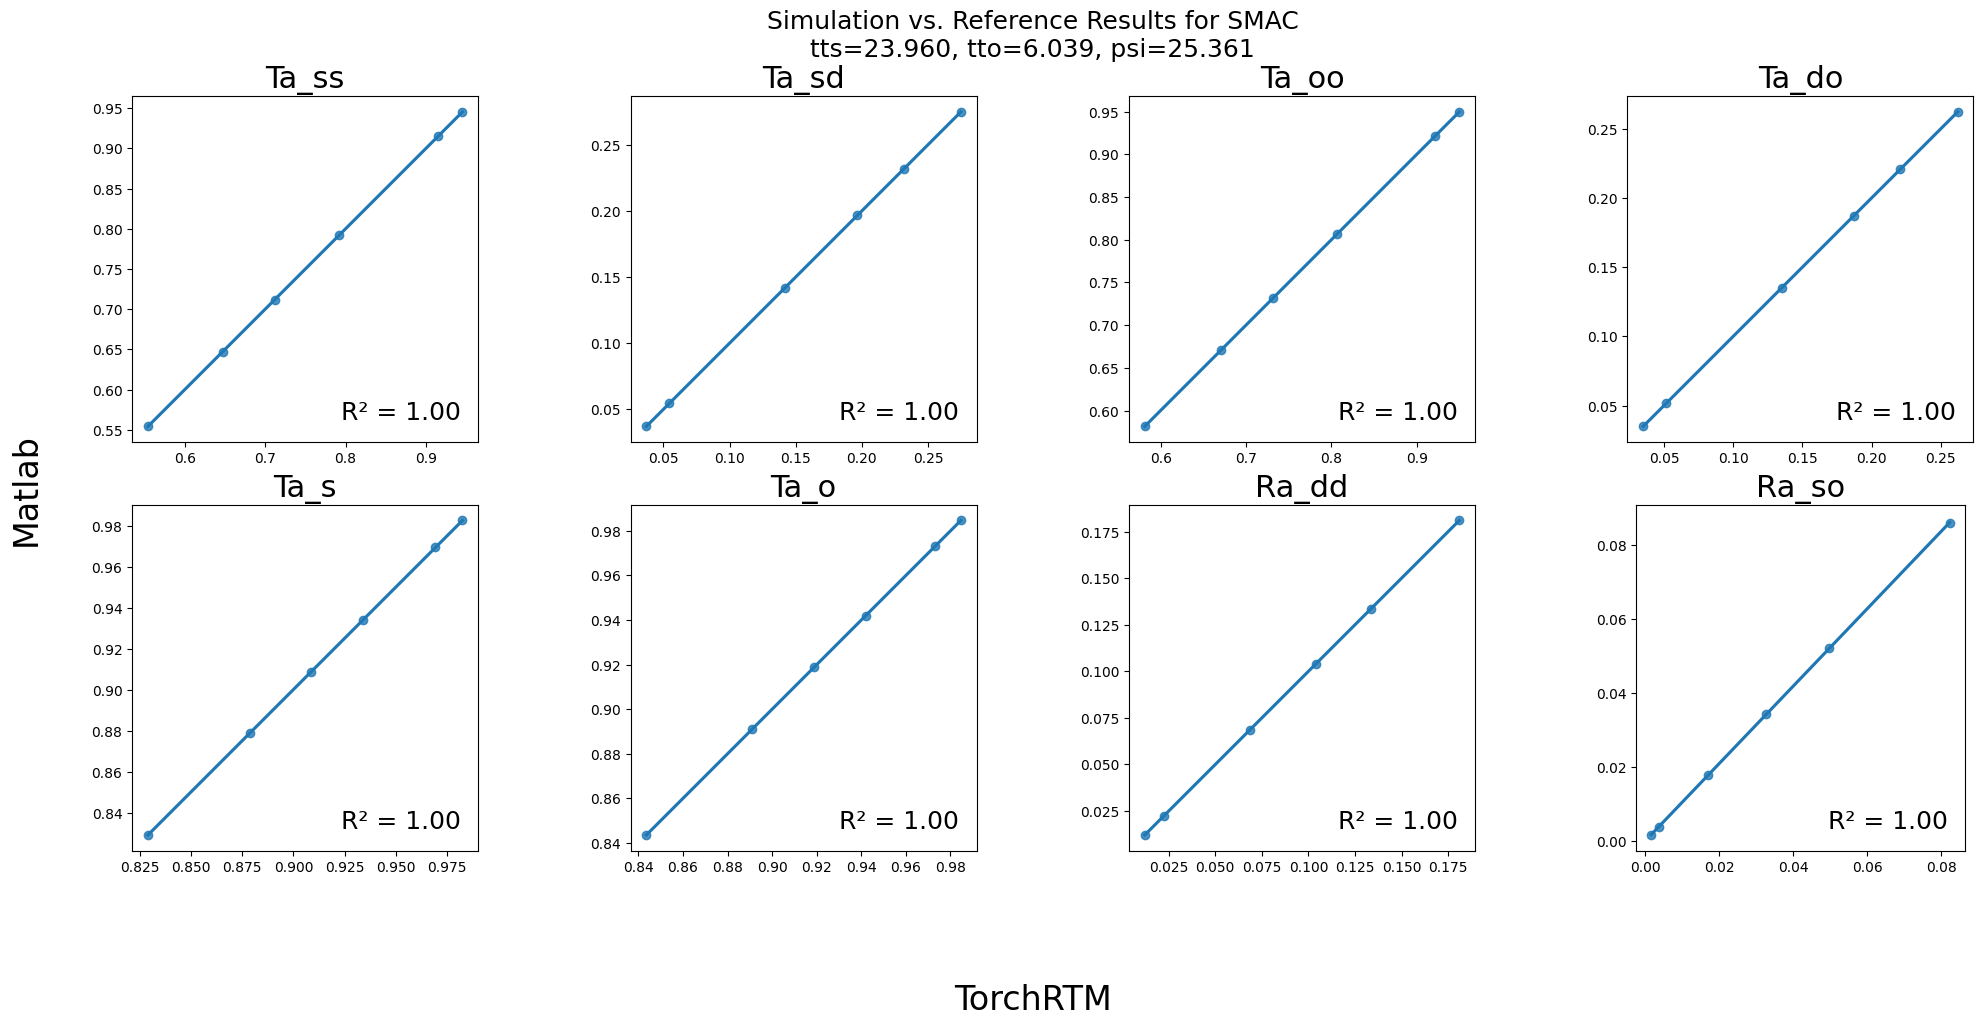

coef_data.mat has been generated and saved!
_____________________________2 time______________________


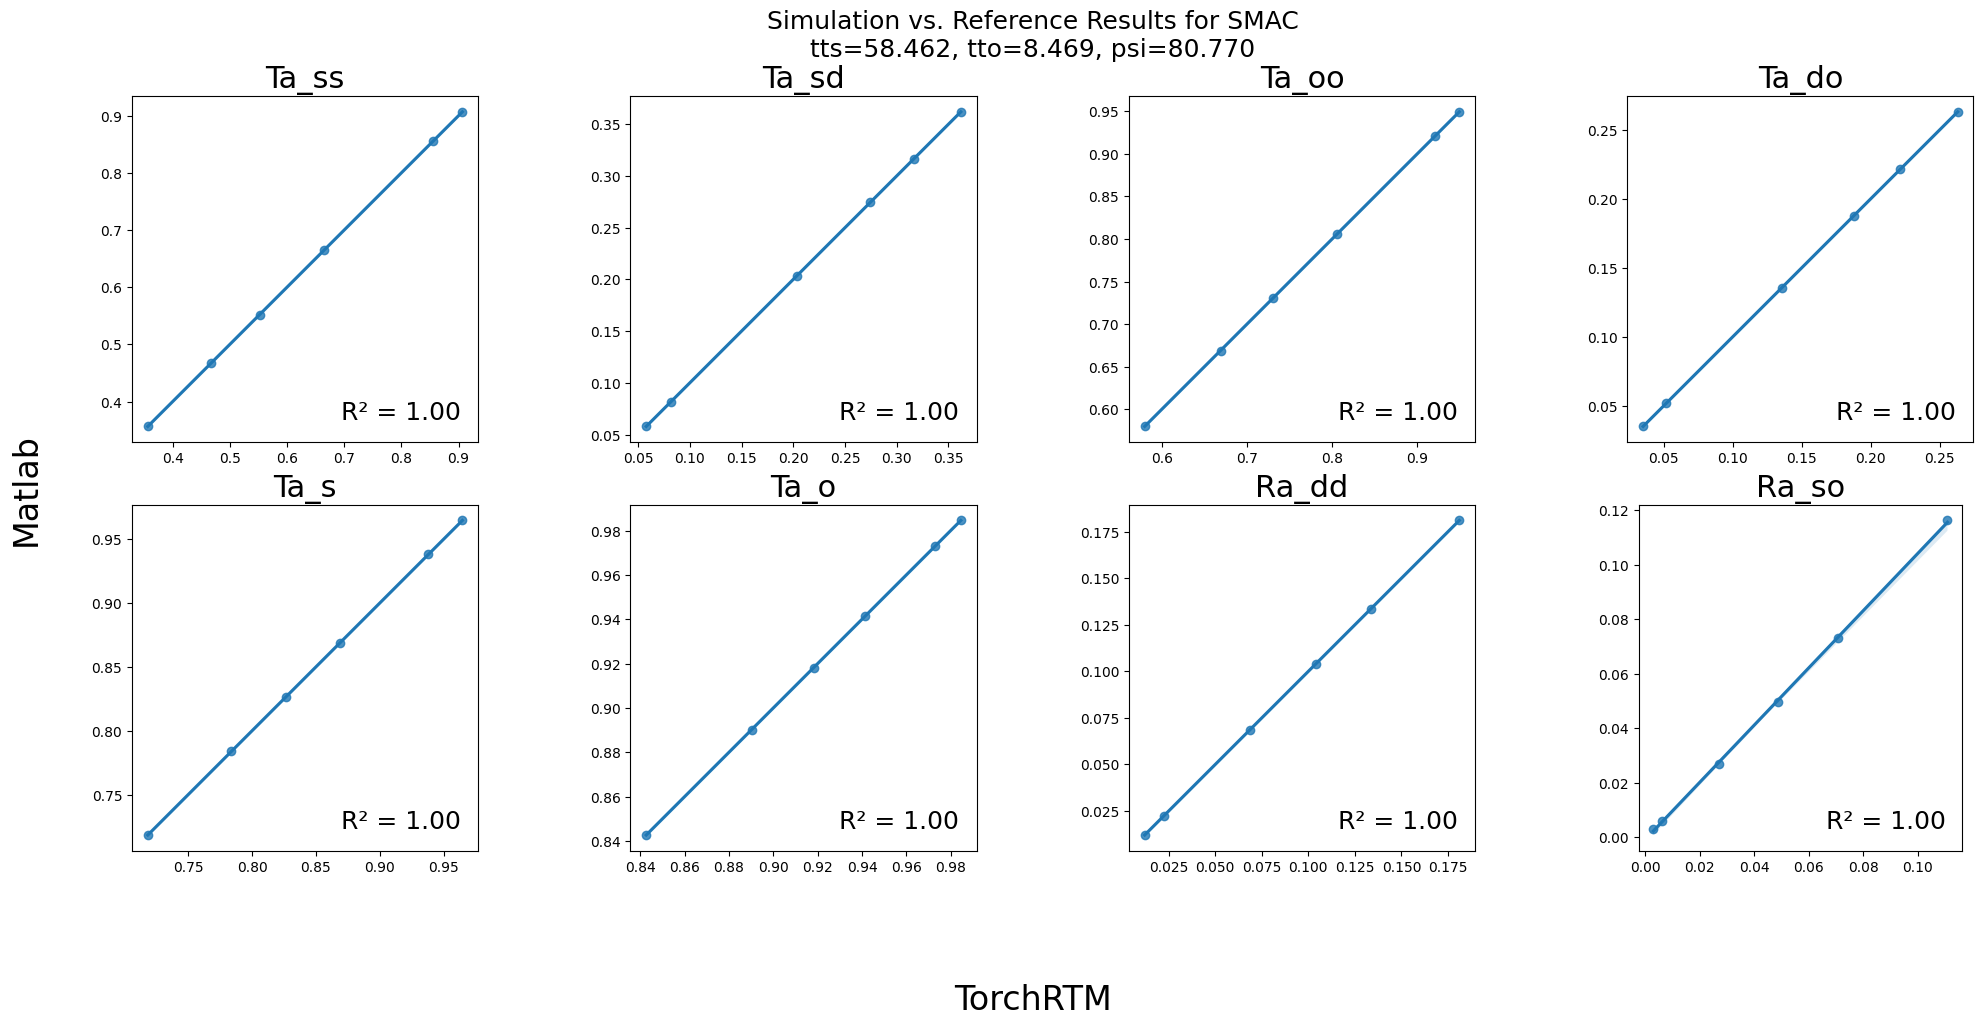

coef_data.mat has been generated and saved!
_____________________________3 time______________________


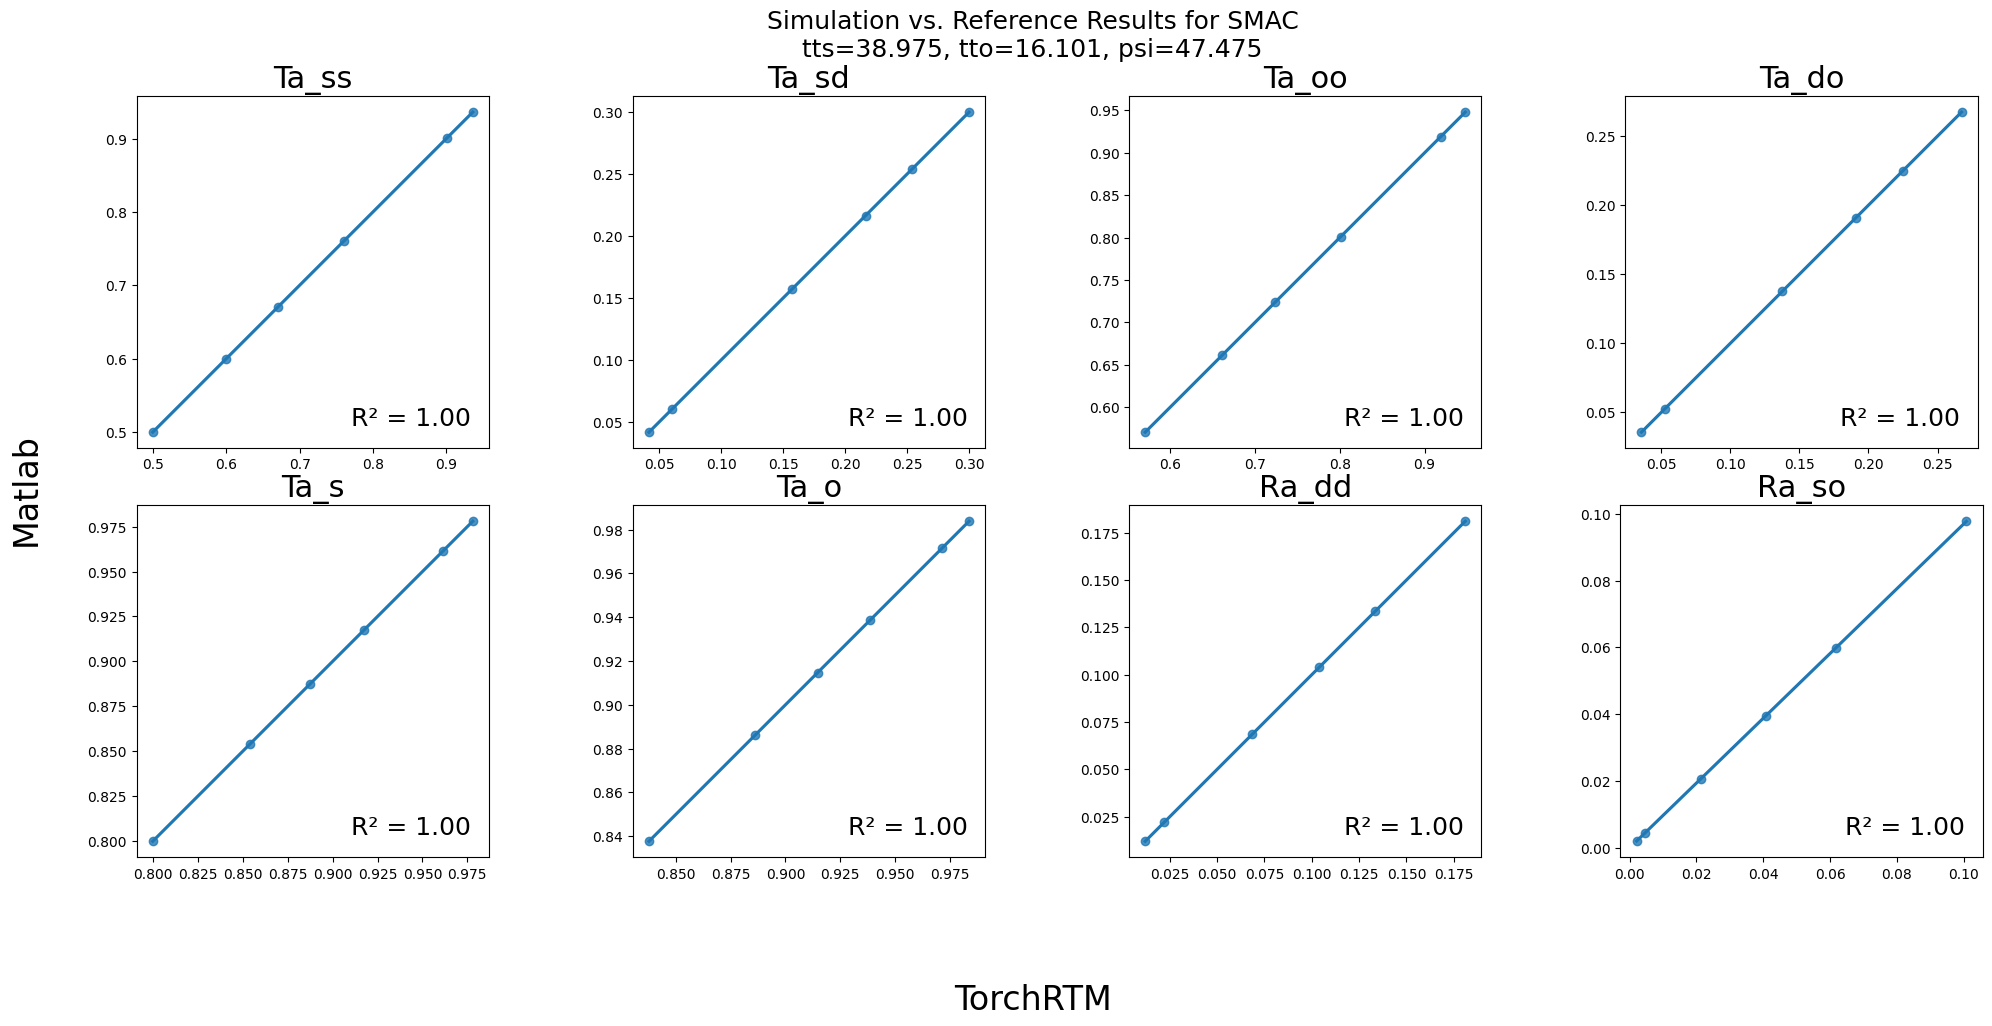

coef_data.mat has been generated and saved!
_____________________________4 time______________________


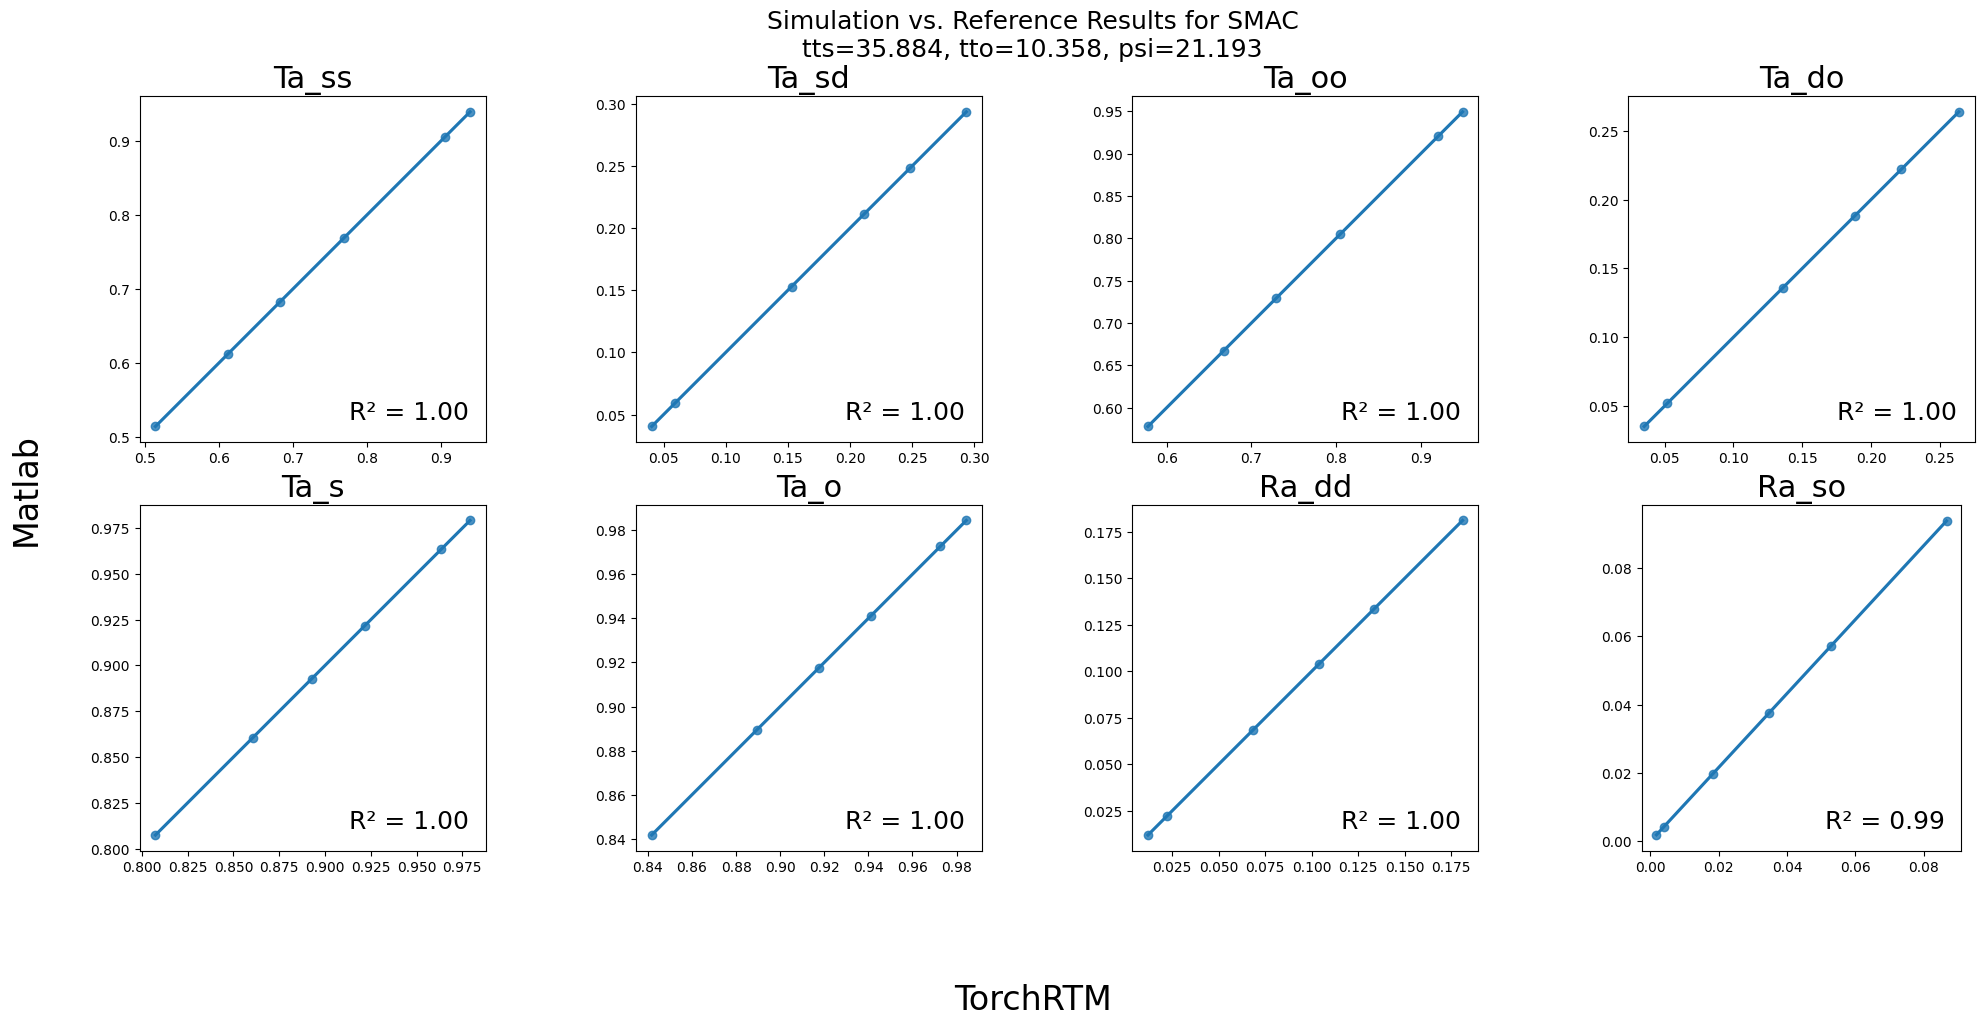

In [ ]:
import scipy.io

# Initial parameters
params = {
    "tts": 30, "tto": 10., "psi": 45.
}

# Number of runs
num_runs = 5

for i in range(num_runs):
    # Generate new parameters, each varying within ±20%
    new_params = {key: value * np.random.uniform(0.1, 2.0) for key, value in params.items()}

    # Save as a .mat file
    scipy.io.savemat('angles_data.mat', {'angles': new_params})

    # Ensure the file is saved successfully
    print("coef_data.mat has been generated and saved!")
    print('_____________________________%s time______________________' % i)

    # Run test_for_smac
    test_for_smac(coefs=coefs, **new_params)
